In [3]:
import sys, json, math, os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, hypergeom, chi2
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))

from qne.cascade.finite_key import h, v, finite_key_output_length, optimize_nu

# --- Core helper functions, reused throughout today's session ---
def asymptotic_key_length(n_bits, Q):
    return max(0, int(n_bits * (1 - 2 * h(Q))))

def verification_t(eps_ec=1e-10):
    return max(1, int(np.ceil(-np.log2(eps_ec))))

def wilson_ci(successes, n, confidence=0.95):
    if n == 0:
        return 0.0, 0.0, 0.0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half_width = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    return p_hat, max(0, center - half_width), min(1, center + half_width)

def two_proportion_ztest(successes1, n1, successes2, n2):
    p1, p2 = successes1 / n1, successes2 / n2
    p_pool = (successes1 + successes2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return np.nan, np.nan
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

def ell_asymptotic_actual(n, k_pe, Q, eps=1e-10):
    """Matches --length-mode asymptotic exactly, as actually collected."""
    t = verification_t(eps)
    ell = asymptotic_key_length(n, Q)
    return ell, t

def is_baseline_contaminated(row):
    resid = row.get("remaining_errors_after_reconciliation", 0)
    resid = 0 if pd.isna(resid) else resid
    return resid > 0

# --- Reconciliation hypergeometric model ---
def block_size_schedule(Q, M=4):
    m1 = math.ceil(0.73 / Q)
    return [m1 * (2 ** (j - 1)) for j in range(1, M + 1)]

def prob_odd_count_hypergeom(N, K, m):
    if K <= 0 or m <= 0:
        return 0.0
    total = 0.0
    for i in range(1, min(K, m) + 1, 2):
        total += hypergeom.pmf(i, N, K, m)
    return total

def prob_even_count_hypergeom_excl(N, K, m):
    if m <= 0:
        return 1.0
    total = 0.0
    for i in range(0, min(K, m) + 1, 2):
        total += hypergeom.pmf(i, N - 1, K, m - 1)
    return total

def background_error_decay(N, Q, M=4):
    m_schedule = block_size_schedule(Q, M)
    K = N * Q
    K_trace = [K]
    C_trace = []
    for m_j in m_schedule:
        n_blocks = N / m_j
        p_odd = prob_odd_count_hypergeom(N, int(round(K)), m_j)
        C_j = n_blocks * p_odd
        K_next = max(0, K - C_j)
        C_trace.append(C_j)
        K_trace.append(K_next)
        K = K_next
    return K_trace, C_trace, m_schedule

def survival_probability_per_pass(N, Q, M=4):
    K_trace, _, m_schedule = background_error_decay(N, Q, M)
    survive = []
    for j, m_j in enumerate(m_schedule):
        K_j = K_trace[j]
        p_survive = prob_even_count_hypergeom_excl(N, int(round(K_j)), m_j)
        survive.append(p_survive)
    return survive

def mismatch_prob_given_pass_injection(N, Q, M=4):
    survive = survival_probability_per_pass(N, Q, M)
    result = {}
    for i in range(M):
        result[i + 1] = float(np.prod(survive[i:]))
    return result, survive

def full_reconciliation_prediction(N, Q, p_recon, M=4):
    K_trace, C_trace, m_schedule = background_error_decay(N, Q, M)
    survive_given_injection, _ = mismatch_prob_given_pass_injection(N, Q, M)
    prob_no_mismatch = 1.0
    for i, C_i in enumerate(C_trace, start=1):
        p_permanent_given_fault = survive_given_injection[i]
        p_this_pass_causes_mismatch = p_recon * p_permanent_given_fault
        prob_no_mismatch *= (1 - p_this_pass_causes_mismatch) ** max(C_i, 0)
    return 1 - prob_no_mismatch

# --- Load real-channel data ---
key_pairs_df = pd.read_csv(str(PROJECT_DIR / "results" / "key_pairs_metadata.csv"))

toeplitz_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_allkeys_asymptotic.csv"))
final_key_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_finalkey_allkeys_asymptotic.csv"))
reconciliation_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_allkeys_asymptotic_fixed.csv"))
verify_digest_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_verifydigest_allkeys_final.csv"))

toeplitz_df["mismatch"] = ~toeplitz_df["keys_match"].fillna(False)
final_key_df["mismatch"] = ~final_key_df["keys_match"].fillna(False)
verify_digest_df["mismatch"] = ~verify_digest_df["keys_match"].fillna(False)

toeplitz_df["is_baseline_contaminated"] = toeplitz_df.apply(is_baseline_contaminated, axis=1)
final_key_df["is_baseline_contaminated"] = final_key_df.apply(is_baseline_contaminated, axis=1)
verify_digest_df["is_baseline_contaminated"] = verify_digest_df.apply(is_baseline_contaminated, axis=1)

toeplitz_clean = toeplitz_df[~toeplitz_df["is_baseline_contaminated"]].copy()
final_key_clean = final_key_df[~final_key_df["is_baseline_contaminated"]].copy()
verify_digest_clean = verify_digest_df[~verify_digest_df["is_baseline_contaminated"]].copy()

# --- Load Mock data -- ADJUST FILENAME to whichever Mock collection you're comparing against ---
mock_path = PROJECT_DIR / "results" / "sdc_mock_allkeys_withverification.csv"
if mock_path.exists():
    mock_df = pd.read_csv(str(mock_path))
    mock_df["mismatch"] = ~mock_df["keys_match"].fillna(False)
    if "remaining_errors_after_reconciliation" in mock_df.columns:
        mock_df["is_baseline_contaminated"] = mock_df.apply(is_baseline_contaminated, axis=1)
        mock_clean = mock_df[~mock_df["is_baseline_contaminated"]].copy()
    else:
        mock_clean = mock_df.copy()
    print(f"Loaded mock_df: {len(mock_df)} rows")
else:
    print(f"WARNING: {mock_path} not found -- check filename, mock_df not loaded")

print("Setup complete.")

Loaded mock_df: 4800 rows
Setup complete.


In [5]:
import pandas as pd
import numpy as np

files_to_check = {
    "toeplitz": str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_allkeys_asymptotic.csv"),
    "final_key": str(PROJECT_DIR / "results" / "sdc_realchannel_finalkey_allkeys_asymptotic.csv"),
    "reconciliation": str(PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_allkeys_asymptotic_fixed.csv"),
    "verify_digest": str(PROJECT_DIR / "results" / "sdc_realchannel_verifydigest_allkeys_final.csv"),
}

dfs = {}
for name, path in files_to_check.items():
    import os
    if not os.path.exists(path):
        print(f"!! {name}: FILE NOT FOUND at {path}\n")
        continue
    df = pd.read_csv(path)
    dfs[name] = df
    print(f"=== {name}: {len(df)} rows ===")
    print(f"Columns: {df.columns.tolist()}\n")

=== toeplitz: 400 rows ===
Columns: ['toeplitz_prob', 'final_key_prob', 'reconciliation_prob', 'verify_digest_prob', 'seed', 'output_path', 'k_pe', 'total_corrections', 'secure_key_length', 't_verify', 'digest_length', 'verification_passed', 'remaining_errors_after_reconciliation', 'non_convergent', 'error', 'elapsed_seconds', 'faults_fired', 'length_mode', 'keys_match', 'alice_measurement_error', 'run', 'bob_output_path', 'alice_output_path', 'code_version', 'collection_timestamp', 'fault_type', 'prob', 'key_index', 'qber']

=== final_key: 400 rows ===
Columns: ['toeplitz_prob', 'final_key_prob', 'reconciliation_prob', 'verify_digest_prob', 'seed', 'output_path', 'k_pe', 'total_corrections', 'secure_key_length', 't_verify', 'digest_length', 'verification_passed', 'remaining_errors_after_reconciliation', 'non_convergent', 'error', 'elapsed_seconds', 'faults_fired', 'length_mode', 'keys_match', 'alice_measurement_error', 'run', 'bob_output_path', 'alice_output_path', 'code_version', 'co

In [6]:
for name, df in dfs.items():
    print(f"--- {name} ---")
    if "code_version" in df.columns:
        print(f"code_version values: {df['code_version'].unique()}")
    else:
        print("NO code_version column -- provenance fix not applied to this collection")
    if "collection_timestamp" in df.columns:
        print(f"collection_timestamp range: {df['collection_timestamp'].min()} to {df['collection_timestamp'].max()}")
    print(f"key_index values: {sorted(df['key_index'].unique())}")
    print(f"length_mode values: {df['length_mode'].unique() if 'length_mode' in df.columns else 'MISSING'}")
    print()

--- toeplitz ---
code_version values: <StringArray>
['unknown']
Length: 1, dtype: str
collection_timestamp range: 2026-08-31T19:40:33.892058 to 2026-08-31T21:41:00.654444
key_index values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
length_mode values: <StringArray>
['asymptotic']
Length: 1, dtype: str

--- final_key ---
code_version values: <StringArray>
['unknown']
Length: 1, dtype: str
collection_timestamp range: 2026-08-31T19:47:13.742270 to 2026-08-31T21:47:58.120693
key_index values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
length_mode values: <StringArray>
['asymptotic']
Length: 1, dtype: str

--- reconciliation ---
NO code_version column -- provenance fix not applied to this collection
key_index values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
length_mode values: <StringArray>
['asymptotic']
Length: 1, dtype: str

--- verify_digest ---
code_version values: <StringArray>
['unknown']
Length: 1, dtype: str
col

In [7]:
def is_baseline_failure(row):
    fired = row.get("faults_fired")
    fired_empty = (fired == "{}" or fired == {} or (isinstance(fired, str) and fired.strip() == "{}"))
    resid = row.get("remaining_errors_after_reconciliation", 0)
    resid = 0 if pd.isna(resid) else resid
    return fired_empty and resid > 0

for name in ["toeplitz", "final_key"]:
    if name not in dfs:
        continue
    df = dfs[name]
    if "faults_fired" not in df.columns:
        print(f"{name}: can't check baseline contamination -- no faults_fired column")
        continue
    df["is_baseline_failure"] = df.apply(is_baseline_failure, axis=1)
    n_contaminated = df["is_baseline_failure"].sum()
    print(f"{name}: {n_contaminated}/{len(df)} baseline-contaminated rows "
          f"({100*n_contaminated/len(df):.1f}%)")
    if n_contaminated > 0:
        print(df[df["is_baseline_failure"]].groupby("key_index").size())
    print()

toeplitz: 12/400 baseline-contaminated rows (3.0%)
key_index
2    4
4    8
dtype: int64

final_key: 16/400 baseline-contaminated rows (4.0%)
key_index
2    8
4    8
dtype: int64



In [8]:
for name, expected_col_val in [("final_key", 1.0), ("toeplitz", 0.5)]:
    if name not in dfs:
        continue
    df = dfs[name]
    sub = df[df["prob"] == df["prob"].max()]
    observed = (~sub["keys_match"].fillna(False)).mean()
    q = sub["prob"].iloc[0]
    print(f"{name} at prob={q}: observed mismatch rate = {observed:.3f}")
    print(f"  one-sided prediction: ~{q * expected_col_val:.3f}")
    print(f"  two-sided prediction: ~{2*q*expected_col_val - (q*expected_col_val)**2:.3f}")
    print(f"  {'Looks one-sided' if abs(observed - q*expected_col_val) < abs(observed - (2*q*expected_col_val - (q*expected_col_val)**2)) else 'CHECK -- looks closer to two-sided'}\n")

final_key at prob=0.5: observed mismatch rate = 0.460
  one-sided prediction: ~0.500
  two-sided prediction: ~0.750
  Looks one-sided

toeplitz at prob=0.5: observed mismatch rate = 0.280
  one-sided prediction: ~0.250
  two-sided prediction: ~0.438
  Looks one-sided



In [9]:
for name in ["toeplitz", "final_key"]:
    if name not in dfs:
        continue
    df = dfs[name]
    violations = df[(df["keys_match"] == False) & (df["verification_passed"] == False)]
    print(f"{name}: {len(violations)} rows with BOTH mismatch AND detected "
          f"(should be 0 -- these two are mutually exclusive by construction)")
    if len(violations) > 0:
        print(violations[["key_index", "prob", "faults_fired", "keys_match", "verification_passed"]].head())
print()

toeplitz: 16 rows with BOTH mismatch AND detected (should be 0 -- these two are mutually exclusive by construction)
     key_index  prob            faults_fired  keys_match  verification_passed
167          2  0.50  {'toeplitz_matrix': 1}       False                False
177          2  0.30  {'toeplitz_matrix': 1}       False                False
187          2  0.10  {'toeplitz_matrix': 1}       False                False
197          2  0.05  {'toeplitz_matrix': 1}       False                False
207          2  0.03                      {}       False                False
final_key: 16 rows with BOTH mismatch AND detected (should be 0 -- these two are mutually exclusive by construction)
     key_index  prob faults_fired  keys_match  verification_passed
167          2  0.50           {}       False                False
177          2  0.30           {}       False                False
187          2  0.10           {}       False                False
197          2  0.05           

In [10]:
if "verify_digest" in dfs:
    df = dfs["verify_digest"]
    n_mismatch = (df["keys_match"] == False).sum()
    print(f"verify_digest: {n_mismatch}/{len(df)} mismatches "
          f"({'OK -- structural result holds' if n_mismatch == 0 else 'VIOLATION -- investigate immediately'})")
    if n_mismatch > 0:
        print(df[df["keys_match"] == False][["key_index", "prob", "faults_fired", "verification_passed"]])
print()

verify_digest: 16/400 mismatches (VIOLATION -- investigate immediately)
     key_index   prob                faults_fired  verification_passed
167          2  0.500  {'verification_digest': 1}                False
177          2  0.300                          {}                False
187          2  0.100                          {}                False
197          2  0.050                          {}                False
207          2  0.030                          {}                False
217          2  0.010                          {}                False
227          2  0.003                          {}                False
237          2  0.001                          {}                False
327          4  0.500  {'verification_digest': 1}                False
337          4  0.300  {'verification_digest': 1}                False
347          4  0.100  {'verification_digest': 1}                False
357          4  0.050  {'verification_digest': 1}                False
367  

In [11]:
if "reconciliation" in dfs:
    df = dfs["reconciliation"]
    print("reconciliation keys_match value counts:", df["keys_match"].value_counts(dropna=False).to_dict())
    print(f"{'FIX CONFIRMED -- real values present' if df['keys_match'].notna().any() else 'STILL BROKEN -- all None'}")
print()

reconciliation keys_match value counts: {False: 246, True: 154}
FIX CONFIRMED -- real values present



In [12]:
for name, df in dfs.items():
    if "elapsed_seconds" not in df.columns:
        continue
    median = df["elapsed_seconds"].median()
    outliers = df[df["elapsed_seconds"] > median * 2]
    print(f"{name}: median={median:.2f}s, {len(outliers)}/{len(df)} rows > 2x median")
    if len(outliers) > 0:
        print(outliers.groupby("key_index")["elapsed_seconds"].agg(["count", "max"]))
print()

toeplitz: median=4.06s, 0/400 rows > 2x median
final_key: median=3.93s, 0/400 rows > 2x median
reconciliation: median=3.87s, 0/400 rows > 2x median
verify_digest: median=3.75s, 0/400 rows > 2x median



In [13]:
for name, df in dfs.items():
    prob_col = "reconciliation_prob" if name == "reconciliation" and "reconciliation_prob" in df.columns else "prob"
    if prob_col not in df.columns:
        continue
    outcome_col = "keys_match"
    grouped = df.groupby(prob_col)[outcome_col].apply(lambda x: (~x.fillna(True)).mean() if name != "reconciliation" else None)
    print(f"{name}: mismatch rate by probability")
    print(grouped)
    print()

toeplitz: mismatch rate by probability
prob
0.001    0.04
0.003    0.04
0.010    0.04
0.030    0.04
0.050    0.12
0.100    0.12
0.300    0.22
0.500    0.28
Name: keys_match, dtype: float64

final_key: mismatch rate by probability
prob
0.001    0.04
0.003    0.04
0.010    0.04
0.030    0.04
0.050    0.10
0.100    0.12
0.300    0.26
0.500    0.46
Name: keys_match, dtype: float64

reconciliation: mismatch rate by probability
reconciliation_prob
0.001    None
0.003    None
0.010    None
0.030    None
0.050    None
0.100    None
0.300    None
0.500    None
Name: keys_match, dtype: object

verify_digest: mismatch rate by probability
prob
0.001    0.04
0.003    0.04
0.010    0.04
0.030    0.04
0.050    0.04
0.100    0.04
0.300    0.04
0.500    0.04
Name: keys_match, dtype: float64



In [14]:
def is_baseline_contaminated(row):
    resid = row.get("remaining_errors_after_reconciliation", 0)
    resid = 0 if pd.isna(resid) else resid
    return resid > 0

for name in ["toeplitz", "final_key", "verify_digest"]:
    if name not in dfs:
        continue
    df = dfs[name]
    df["is_baseline_contaminated"] = df.apply(is_baseline_contaminated, axis=1)
    n = df["is_baseline_contaminated"].sum()
    print(f"{name}: {n}/{len(df)} contaminated rows ({100*n/len(df):.1f}%)")
    print(df[df["is_baseline_contaminated"]].groupby("key_index").size())

    # Re-check structural violations on CLEANED data
    clean = df[~df["is_baseline_contaminated"]]
    violations_clean = clean[(clean["keys_match"] == False) & (clean["verification_passed"] == False)]
    print(f"  violations after cleaning: {len(violations_clean)} (should be 0)\n")

toeplitz: 16/400 contaminated rows (4.0%)
key_index
2    8
4    8
dtype: int64
  violations after cleaning: 0 (should be 0)

final_key: 16/400 contaminated rows (4.0%)
key_index
2    8
4    8
dtype: int64
  violations after cleaning: 0 (should be 0)

verify_digest: 16/400 contaminated rows (4.0%)
key_index
2    8
4    8
dtype: int64
  violations after cleaning: 0 (should be 0)



In [15]:
if "reconciliation" in dfs:
    df = dfs["reconciliation"]
    grouped = df.groupby("reconciliation_prob")["keys_match"].apply(lambda x: (~x.fillna(True)).mean())
    print("reconciliation: mismatch rate by probability (real keys_match)")
    print(grouped)

reconciliation: mismatch rate by probability (real keys_match)
reconciliation_prob
0.001    0.04
0.003    0.04
0.010    0.24
0.030    0.74
0.050    0.86
0.100    1.00
0.300    1.00
0.500    1.00
Name: keys_match, dtype: float64


In [16]:
# --- Apply cleaning filter to toeplitz/final_key/verify_digest ---
def is_baseline_contaminated(row):
    resid = row.get("remaining_errors_after_reconciliation", 0)
    resid = 0 if pd.isna(resid) else resid
    return resid > 0

for name in ["toeplitz", "final_key", "verify_digest"]:
    dfs[name]["is_baseline_contaminated"] = dfs[name].apply(is_baseline_contaminated, axis=1)

toeplitz_clean = dfs["toeplitz"][~dfs["toeplitz"]["is_baseline_contaminated"]].copy()
final_key_clean = dfs["final_key"][~dfs["final_key"]["is_baseline_contaminated"]].copy()
verify_digest_clean = dfs["verify_digest"][~dfs["verify_digest"]["is_baseline_contaminated"]].copy()
reconciliation_df = dfs["reconciliation"].copy()  # no cleaning needed -- this IS the signal

for name, df in [("toeplitz", toeplitz_clean), ("final_key", final_key_clean),
                   ("verify_digest", verify_digest_clean)]:
    df["mismatch"] = ~df["keys_match"].fillna(False)

print("=== Cleaned mismatch rate by probability ===")
for name, df in [("toeplitz", toeplitz_clean), ("final_key", final_key_clean),
                   ("verify_digest", verify_digest_clean)]:
    summary = df.groupby("prob")["mismatch"].agg(["mean", "std", "count"])
    print(f"\n{name}:\n{summary}")

print(f"\nreconciliation:\n{reconciliation_df.groupby('reconciliation_prob').apply(lambda g: (~g['keys_match'].fillna(True)).mean())}")

=== Cleaned mismatch rate by probability ===

toeplitz:
           mean       std  count
prob                            
0.001  0.000000  0.000000     48
0.003  0.000000  0.000000     48
0.010  0.000000  0.000000     48
0.030  0.000000  0.000000     48
0.050  0.083333  0.279310     48
0.100  0.083333  0.279310     48
0.300  0.187500  0.394443     48
0.500  0.250000  0.437595     48

final_key:
           mean       std  count
prob                            
0.001  0.000000  0.000000     48
0.003  0.000000  0.000000     48
0.010  0.000000  0.000000     48
0.030  0.000000  0.000000     48
0.050  0.062500  0.244623     48
0.100  0.083333  0.279310     48
0.300  0.229167  0.424744     48
0.500  0.437500  0.501328     48

verify_digest:
       mean  std  count
prob                   
0.001   0.0  0.0     48
0.003   0.0  0.0     48
0.010   0.0  0.0     48
0.030   0.0  0.0     48
0.050   0.0  0.0     48
0.100   0.0  0.0     48
0.300   0.0  0.0     48
0.500   0.0  0.0     48

reconciliation:

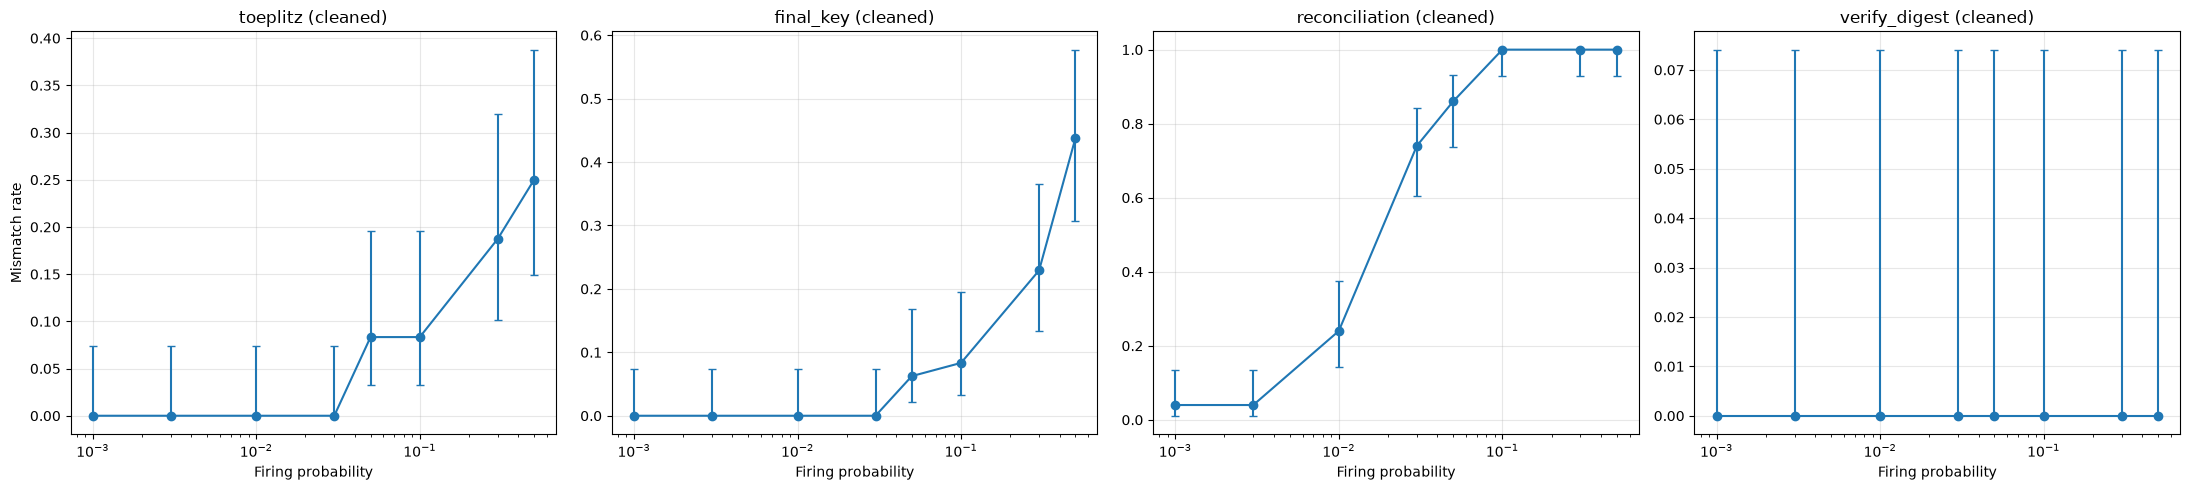

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, df, prob_col) in zip(axes, [
    ("toeplitz", toeplitz_clean, "prob"), ("final_key", final_key_clean, "prob"),
    ("reconciliation", reconciliation_df, "reconciliation_prob"), ("verify_digest", verify_digest_clean, "prob")]):

    grouped = df.groupby(prob_col).apply(lambda g: pd.Series(
        wilson_ci((~g["keys_match"].fillna(True)).sum(), len(g)), index=["mean", "lo", "hi"]))

    # Clip tiny negative floating-point artifacts at the zero boundary --
    # Wilson's interval always mathematically contains the point estimate;
    # values like -2e-17 here are rounding noise, not real negative errors.
    yerr_lower = np.clip(grouped["mean"] - grouped["lo"], 0, None)
    yerr_upper = np.clip(grouped["hi"] - grouped["mean"], 0, None)

    ax.errorbar(grouped.index, grouped["mean"], yerr=[yerr_lower, yerr_upper],
                  fmt="o-", capsize=3)
    ax.set_xscale("log")
    ax.set_title(f"{name} (cleaned)")
    ax.set_xlabel("Firing probability")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Mismatch rate")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_final_cleaned_all_faults.png"), dpi=150)
plt.show()

In [18]:
from qne.cascade.finite_key import h, v, finite_key_output_length, optimize_nu

In [19]:
import inspect
print(inspect.signature(optimize_nu))

(n, k, Q, eps_ec=1e-10, eps_pa=1e-10, c_bar=0.5, n_grid=2000, r_override=None)


In [20]:
def ell_idealized(n, k_pe, Q, eps=1e-10, eps_pa=1e-10):
    """finite-key ell using the IDEALIZED Corollary 2 bound (no fitted correction)."""
    cbar = 0.5
    t = verification_t(eps)
    nu, _, r_idealized, _ = optimize_nu(n, k_pe, Q, eps_ec=eps, eps_pa=eps_pa, c_bar=cbar)
    ell = n * (np.log2(1 / cbar) - h(Q + nu)) - r_idealized - t - 2 * np.log2(1 / (2 * eps_pa))
    return max(0, ell), t

def ell_fitted(n, k_pe, Q, xi1_hat=2.35, eps=1e-10, eps_pa=1e-10):
    """finite-key ell using the FITTED xi1 -- nu is now optimized AGAINST
    this same fitted leakage, via r_override, not borrowed from the
    idealized-leakage optimization."""
    cbar = 0.5
    t = verification_t(eps)
    r_fitted = xi1_hat * n * h(Q)
    nu, _, r_used, _ = optimize_nu(n, k_pe, Q, eps_ec=eps, eps_pa=eps_pa, c_bar=cbar, r_override=r_fitted)
    ell = n * (np.log2(1 / cbar) - h(Q + nu)) - r_used - t - 2 * np.log2(1 / (2 * eps_pa))
    return max(0, ell), t


def validate_toeplitz(df_clean, key_pairs_df, ell_func, p1, label):
    print(f"=== Toeplitz validation: {label} ===")
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            n_trials = len(trials)
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, n_trials)
            predicted = prob * (ell / (ell + t_verify)) * p1
            in_ci = lo <= predicted <= hi
            print(f"  key{key_idx} q={prob:<6}: observed={p_hat:.3f}[{lo:.3f},{hi:.3f}] "
                  f"predicted={predicted:.3f} (ell={ell:.0f}, t={t_verify}) "
                  f"{'OK' if in_ci else 'OUTSIDE'}")

def validate_final_key(df_clean, key_pairs_df, ell_func, label):
    print(f"=== Final-key validation: {label} ===")
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            n_trials = len(trials)
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, n_trials)
            predicted = prob * (ell / (ell + t_verify))
            in_ci = lo <= predicted <= hi
            print(f"  key{key_idx} q={prob:<6}: observed={p_hat:.3f}[{lo:.3f},{hi:.3f}] "
                  f"predicted={predicted:.3f} (ell={ell:.0f}, t={t_verify}) "
                  f"{'OK' if in_ci else 'OUTSIDE'}")

validate_toeplitz(toeplitz_clean, key_pairs_df, ell_idealized, p1=0.5, label="idealized leakage")
print()
validate_toeplitz(toeplitz_clean, key_pairs_df, ell_fitted, p1=0.5, label="fitted xi1 leakage")
print()
validate_final_key(final_key_clean, key_pairs_df, ell_idealized, label="idealized leakage")
print()
validate_final_key(final_key_clean, key_pairs_df, ell_fitted, label="fitted xi1 leakage")

=== Toeplitz validation: idealized leakage ===
  key0 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=8, t=34) OK
  key0 q=0.003 : observed=0.000[0.000,0.278] predicted=0.000 (ell=8, t=34) OK
  key0 q=0.01  : observed=0.000[0.000,0.278] predicted=0.001 (ell=8, t=34) OK
  key0 q=0.03  : observed=0.000[0.000,0.278] predicted=0.003 (ell=8, t=34) OK
  key0 q=0.05  : observed=0.000[0.000,0.278] predicted=0.005 (ell=8, t=34) OK
  key0 q=0.1   : observed=0.000[0.000,0.278] predicted=0.010 (ell=8, t=34) OK
  key0 q=0.3   : observed=0.200[0.057,0.510] predicted=0.030 (ell=8, t=34) OUTSIDE
  key0 q=0.5   : observed=0.200[0.057,0.510] predicted=0.050 (ell=8, t=34) OUTSIDE
  key1 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=0, t=34) OK
  key1 q=0.003 : observed=0.000[0.000,0.278] predicted=0.000 (ell=0, t=34) OK
  key1 q=0.01  : observed=0.000[0.000,0.278] predicted=0.000 (ell=0, t=34) OK
  key1 q=0.03  : observed=0.000[0.000,0.278] predicted=0.000 (ell=0, t=34) OK
  key1 

In [21]:
from scipy.stats import hypergeom
import math

def block_size_schedule(Q, M=4):
    """m_1 = ceil(0.73/QBER), m_j = m_1 * 2^(j-1)."""
    m1 = math.ceil(0.73 / Q)
    return [m1 * (2 ** (j - 1)) for j in range(1, M + 1)]

def prob_odd_count_hypergeom(N, K, m):
    """Sum over odd i of hypergeometric(i; N, K, m) -- probability an
    m-sized draw from N items (K of them 'marked') contains an odd count."""
    if K <= 0 or m <= 0:
        return 0.0
    total = 0.0
    for i in range(1, min(K, m) + 1, 2):
        total += hypergeom.pmf(i, N, K, m)
    return total

def prob_even_count_hypergeom_excl(N, K, m):
    """P_survive(j): probability an even number of the K background errors
    join a SPECIFIC already-placed error's block (m-1 more slots drawn
    from N-1 remaining positions, since that one slot is already taken)."""
    if m <= 0:
        return 1.0
    total = 0.0
    for i in range(0, min(K, m) + 1, 2):
        total += hypergeom.pmf(i, N - 1, K, m - 1)
    return total

def background_error_decay(N, Q, M=4):
    """K_1 = N*QBER; K_{j+1} = K_j - (N/m_j) * P(odd count in a block)."""
    m_schedule = block_size_schedule(Q, M)
    K = N * Q
    K_trace = [K]
    C_trace = []
    for m_j in m_schedule:
        n_blocks = N / m_j
        p_odd = prob_odd_count_hypergeom(N, int(round(K)), m_j)
        C_j = n_blocks * p_odd
        K_next = max(0, K - C_j)
        C_trace.append(C_j)
        K_trace.append(K_next)
        K = K_next
    return K_trace, C_trace, m_schedule

def survival_probability_per_pass(N, Q, M=4):
    """P_survive(j) for each pass j = 1..M."""
    K_trace, _, m_schedule = background_error_decay(N, Q, M)
    survive = []
    for j, m_j in enumerate(m_schedule):
        K_j = K_trace[j]
        p_survive = prob_even_count_hypergeom_excl(N, int(round(K_j)), m_j)
        survive.append(p_survive)
    return survive

def mismatch_prob_given_pass_injection(N, Q, M=4):
    """P(mismatch | injected at pass i) = product of survival, pass i through M."""
    survive = survival_probability_per_pass(N, Q, M)
    result = {}
    for i in range(M):
        result[i + 1] = float(np.prod(survive[i:]))
    return result, survive

def full_reconciliation_prediction(N, Q, p_recon, M=4):
    """Combine across all passes: at pass i, C_i corrections occur, each
    independently faulted with probability p_recon; a faulted correction
    causes a PERMANENT mismatch only if it survives every remaining pass."""
    K_trace, C_trace, m_schedule = background_error_decay(N, Q, M)
    survive_given_injection, _ = mismatch_prob_given_pass_injection(N, Q, M)

    prob_no_mismatch = 1.0
    for i, C_i in enumerate(C_trace, start=1):
        p_permanent_given_fault = survive_given_injection[i]
        p_this_pass_causes_mismatch = p_recon * p_permanent_given_fault
        prob_no_mismatch *= (1 - p_this_pass_causes_mismatch) ** max(C_i, 0)
    return 1 - prob_no_mismatch


def validate_reconciliation(df, key_pairs_df, M=4):
    print("=== Reconciliation validation: hypergeometric model ===")
    for key_idx in sorted(df["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, Q = int(krow["n_bits"]), float(krow["qber"])

        # Report the derived block schedule + background-error trace once per key
        K_trace, C_trace, m_schedule = background_error_decay(n_bits, Q, M)
        print(f"  key{key_idx}: m_schedule={m_schedule}, K_trace={[f'{k:.2f}' for k in K_trace]}, "
              f"C_trace={[f'{c:.2f}' for c in C_trace]}")

        sub = df[df["key_index"] == key_idx]
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            successes = (~trials["keys_match"].fillna(True)).sum()
            p_hat, lo, hi = wilson_ci(successes, n_trials)
            predicted = full_reconciliation_prediction(n_bits, Q, prob, M)
            in_ci = lo <= predicted <= hi
            print(f"    q={prob:<6}: observed={p_hat:.3f}[{lo:.3f},{hi:.3f}] "
                  f"predicted={predicted:.3f} {'OK' if in_ci else 'OUTSIDE'}")

validate_reconciliation(reconciliation_df, key_pairs_df)

=== Reconciliation validation: hypergeometric model ===
  key0: m_schedule=[57, 114, 228, 456], K_trace=['44.92', '20.99', '9.33', '3.83', '1.14'], C_trace=['23.93', '11.66', '5.50', '2.69']
    q=0.001 : observed=0.000[0.000,0.278] predicted=0.011 OK
    q=0.003 : observed=0.000[0.000,0.278] predicted=0.032 OK
    q=0.01  : observed=0.200[0.057,0.510] predicted=0.103 OK
    q=0.03  : observed=0.700[0.397,0.892] predicted=0.280 OUTSIDE
    q=0.05  : observed=0.800[0.490,0.943] predicted=0.423 OUTSIDE
    q=0.1   : observed=1.000[0.722,1.000] predicted=0.670 OUTSIDE
    q=0.3   : observed=1.000[0.722,1.000] predicted=0.968 OK
    q=0.5   : observed=1.000[0.722,1.000] predicted=0.997 OK
  key1: m_schedule=[47, 94, 188, 376], K_trace=['53.97', '25.52', '11.49', '4.92', '1.69'], C_trace=['28.45', '14.03', '6.57', '3.23']
    q=0.001 : observed=0.000[0.000,0.278] predicted=0.013 OK
    q=0.003 : observed=0.000[0.000,0.278] predicted=0.037 OK
    q=0.01  : observed=0.200[0.057,0.510] predict

In [22]:
def ell_asymptotic_actual(n, k_pe, Q, eps=1e-10):
    """Matches EXACTLY what --length-mode asymptotic computed when this
    data was collected -- the simple asymptotic formula, no finite-key
    correction at all."""
    t = verification_t(eps)
    ell = asymptotic_key_length(n, Q)
    return ell, t

validate_toeplitz(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="asymptotic (matches actual collection)")
print()
validate_final_key(final_key_clean, key_pairs_df, ell_asymptotic_actual, label="asymptotic (matches actual collection)")

=== Toeplitz validation: asymptotic (matches actual collection) ===
  key0 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=2810, t=34) OK
  key0 q=0.003 : observed=0.000[0.000,0.278] predicted=0.001 (ell=2810, t=34) OK
  key0 q=0.01  : observed=0.000[0.000,0.278] predicted=0.005 (ell=2810, t=34) OK
  key0 q=0.03  : observed=0.000[0.000,0.278] predicted=0.015 (ell=2810, t=34) OK
  key0 q=0.05  : observed=0.000[0.000,0.278] predicted=0.025 (ell=2810, t=34) OK
  key0 q=0.1   : observed=0.000[0.000,0.278] predicted=0.049 (ell=2810, t=34) OK
  key0 q=0.3   : observed=0.200[0.057,0.510] predicted=0.148 (ell=2810, t=34) OK
  key0 q=0.5   : observed=0.200[0.057,0.510] predicted=0.247 (ell=2810, t=34) OK
  key1 q=0.001 : observed=0.000[0.000,0.278] predicted=0.000 (ell=2608, t=34) OK
  key1 q=0.003 : observed=0.000[0.000,0.278] predicted=0.001 (ell=2608, t=34) OK
  key1 q=0.01  : observed=0.000[0.000,0.278] predicted=0.005 (ell=2608, t=34) OK
  key1 q=0.03  : observed=0.000[0.000,0.2

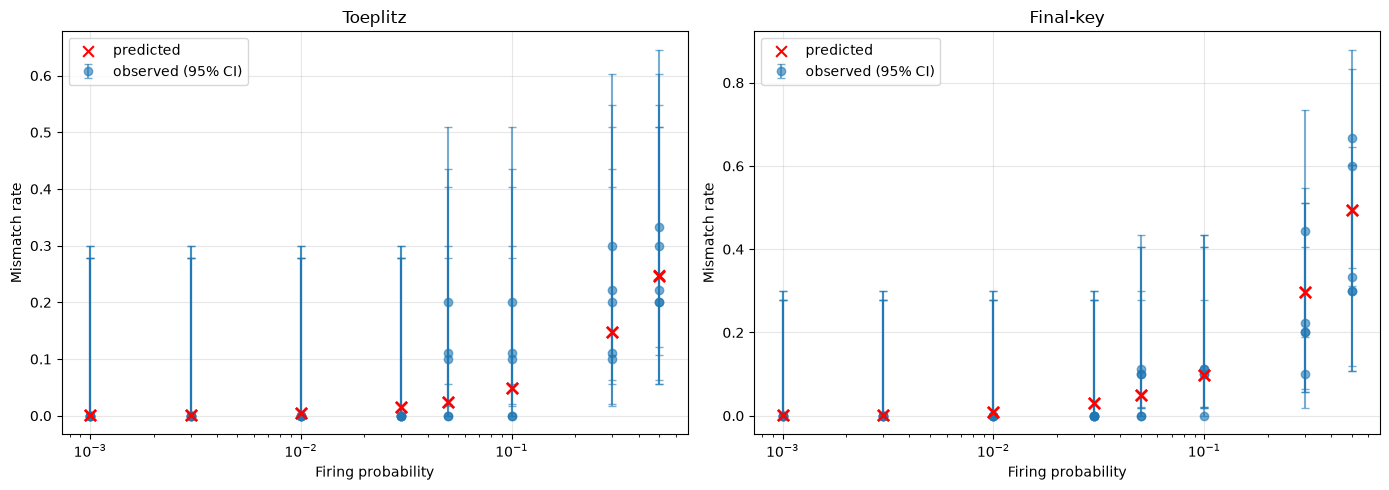

In [23]:
def plot_validation(df_clean, key_pairs_df, ell_func, p1, label, ax, fault_type="toeplitz"):
    all_q, all_obs, all_lo, all_hi, all_pred = [], [], [], [], []
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, len(trials))
            predicted = prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0)
            all_q.append(prob); all_obs.append(p_hat); all_lo.append(lo); all_hi.append(hi)
            all_pred.append(predicted)

    all_obs, all_lo, all_hi = np.array(all_obs), np.array(all_lo), np.array(all_hi)
    yerr_lower = np.clip(all_obs - all_lo, 0, None)  # clip rounding-noise negatives
    yerr_upper = np.clip(all_hi - all_obs, 0, None)

    ax.errorbar(all_q, all_obs, yerr=[yerr_lower, yerr_upper],
                  fmt="o", capsize=3, label="observed (95% CI)", alpha=0.6)
    ax.scatter(all_q, all_pred, marker="x", color="red", s=60, label="predicted", zorder=5)
    ax.set_xscale("log")
    ax.set_xlabel("Firing probability")
    ax.set_ylabel("Mismatch rate")
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_validation(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="Toeplitz", ax=axes[0])
plot_validation(final_key_clean, key_pairs_df, ell_asymptotic_actual, p1=None, label="Final-key", ax=axes[1])
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_toeplitz_finalkey_validation.png"), dpi=150)
plt.show()

In [24]:
from scipy.stats import chi2

def chi_square_goodness_of_fit(df_clean, key_pairs_df, ell_func, p1):
    chi2_stat = 0
    dof = 0
    for key_idx in sorted(df_clean["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            n_trials = len(trials)
            observed_successes = trials["mismatch"].sum()
            predicted_p = prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0)
            predicted_p = min(max(predicted_p, 1e-6), 1 - 1e-6)  # avoid divide-by-zero
            expected_successes = n_trials * predicted_p
            expected_failures = n_trials * (1 - predicted_p)
            observed_failures = n_trials - observed_successes
            if expected_successes > 0:
                chi2_stat += (observed_successes - expected_successes) ** 2 / expected_successes
            if expected_failures > 0:
                chi2_stat += (observed_failures - expected_failures) ** 2 / expected_failures
            dof += 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, dof, p_value

chi2_stat, dof, p_val = chi_square_goodness_of_fit(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5)
print(f"Toeplitz goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")
print(f"{'Formula NOT rejected (good fit)' if p_val > 0.05 else 'Formula rejected -- systematic deviation'}")

chi2_stat, dof, p_val = chi_square_goodness_of_fit(final_key_clean, key_pairs_df, ell_asymptotic_actual, p1=None)
print(f"Final-key goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")
print(f"{'Formula NOT rejected (good fit)' if p_val > 0.05 else 'Formula rejected -- systematic deviation'}")

Toeplitz goodness-of-fit: chi2=30.03, dof=40, p=0.8744
Formula NOT rejected (good fit)
Final-key goodness-of-fit: chi2=15.44, dof=40, p=0.9998
Formula NOT rejected (good fit)


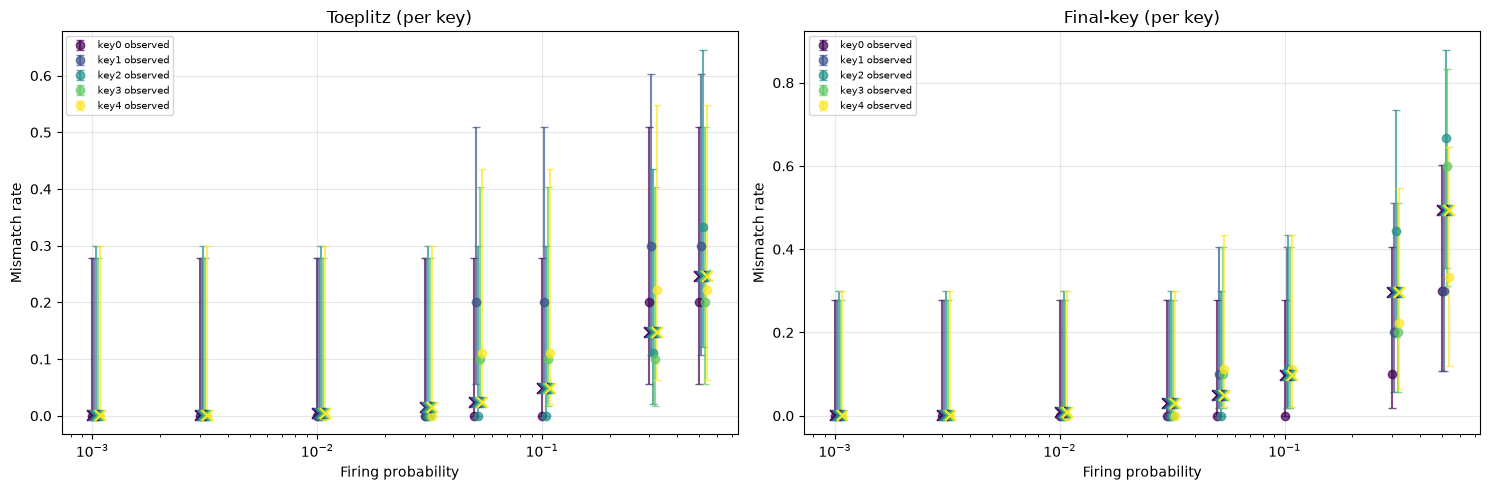

In [25]:
def plot_validation(df_clean, key_pairs_df, ell_func, p1, label, ax):
    colors = plt.cm.viridis(np.linspace(0, 1, len(df_clean["key_index"].unique())))
    for color, key_idx in zip(colors, sorted(df_clean["key_index"].unique())):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
        ell, t_verify = ell_func(n_bits, k_pe, Q)
        sub = df_clean[df_clean["key_index"] == key_idx]

        qs, obs, los, his, preds = [], [], [], [], []
        for prob in sorted(sub["prob"].unique()):
            trials = sub[sub["prob"] == prob]
            successes = trials["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, len(trials))
            predicted = prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0)
            qs.append(prob); obs.append(p_hat); los.append(lo); his.append(hi); preds.append(predicted)

        obs, los, his = np.array(obs), np.array(los), np.array(his)
        yerr_lower = np.clip(obs - los, 0, None)
        yerr_upper = np.clip(his - obs, 0, None)

        # Small horizontal jitter per key so overlapping x-values separate visually
        qs_jittered = np.array(qs) * (1 + 0.02 * key_idx)

        ax.errorbar(qs_jittered, obs, yerr=[yerr_lower, yerr_upper], fmt="o", capsize=3,
                       color=color, alpha=0.7, label=f"key{key_idx} observed")
        ax.scatter(qs_jittered, preds, marker="x", color=color, s=60, zorder=5)

    ax.set_xscale("log")
    ax.set_xlabel("Firing probability")
    ax.set_ylabel("Mismatch rate")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_validation(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="Toeplitz (per key)", ax=axes[0])
plot_validation(final_key_clean, key_pairs_df, ell_asymptotic_actual, p1=None, label="Final-key (per key)", ax=axes[1])
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_toeplitz_finalkey_validation_perkey.png"), dpi=150)
plt.show()

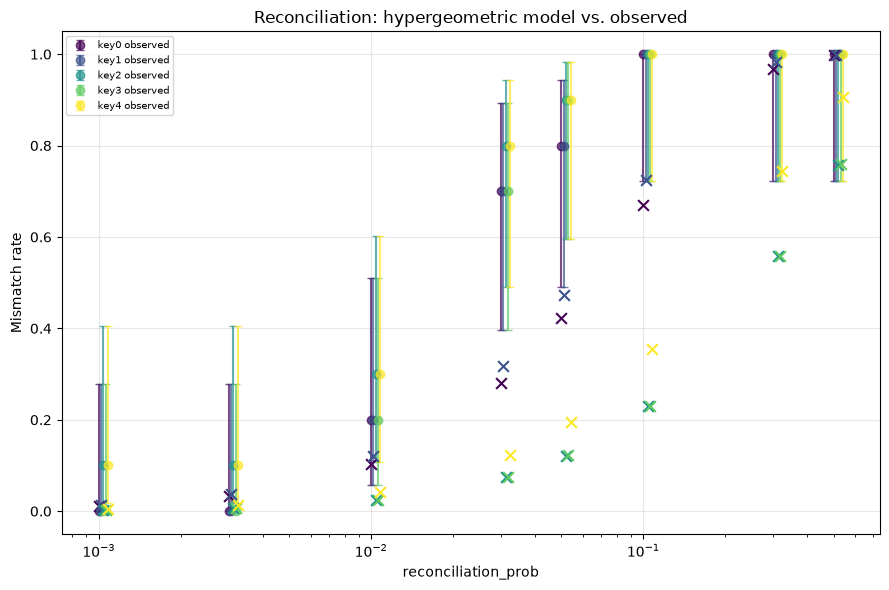

In [26]:
def plot_reconciliation_validation(df, key_pairs_df, M=4):
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(df["key_index"].unique())))

    for color, key_idx in zip(colors, sorted(df["key_index"].unique())):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, Q = int(krow["n_bits"]), float(krow["qber"])
        sub = df[df["key_index"] == key_idx]

        qs, obs, los, his, preds = [], [], [], [], []
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            successes = (~trials["keys_match"].fillna(True)).sum()
            p_hat, lo, hi = wilson_ci(successes, len(trials))
            predicted = full_reconciliation_prediction(n_bits, Q, prob, M)
            qs.append(prob); obs.append(p_hat); los.append(lo); his.append(hi); preds.append(predicted)

        obs, los, his = np.array(obs), np.array(los), np.array(his)
        yerr_lower = np.clip(obs - los, 0, None)
        yerr_upper = np.clip(his - obs, 0, None)
        qs_jittered = np.array(qs) * (1 + 0.02 * key_idx)

        ax.errorbar(qs_jittered, obs, yerr=[yerr_lower, yerr_upper], fmt="o", capsize=3,
                       color=color, alpha=0.7, label=f"key{key_idx} observed")
        ax.scatter(qs_jittered, preds, marker="x", color=color, s=60, zorder=5)

    ax.set_xscale("log")
    ax.set_xlabel("reconciliation_prob")
    ax.set_ylabel("Mismatch rate")
    ax.set_title("Reconciliation: hypergeometric model vs. observed")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(PROJECT_DIR / "results" / "fig_reconciliation_validation.png"), dpi=150)
    plt.show()

plot_reconciliation_validation(reconciliation_df, key_pairs_df)

In [27]:
def chi_square_goodness_of_fit_reconciliation(df, key_pairs_df, M=4):
    chi2_stat = 0
    dof = 0
    for key_idx in sorted(df["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, Q = int(krow["n_bits"]), float(krow["qber"])
        sub = df[df["key_index"] == key_idx]
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            observed_successes = (~trials["keys_match"].fillna(True)).sum()
            predicted_p = full_reconciliation_prediction(n_bits, Q, prob, M)
            predicted_p = min(max(predicted_p, 1e-6), 1 - 1e-6)
            expected_successes = n_trials * predicted_p
            expected_failures = n_trials * (1 - predicted_p)
            observed_failures = n_trials - observed_successes
            if expected_successes > 0:
                chi2_stat += (observed_successes - expected_successes) ** 2 / expected_successes
            if expected_failures > 0:
                chi2_stat += (observed_failures - expected_failures) ** 2 / expected_failures
            dof += 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, dof, p_value

chi2_stat, dof, p_val = chi_square_goodness_of_fit_reconciliation(reconciliation_df, key_pairs_df)
print(f"Reconciliation goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")
print(f"{'Formula NOT rejected (good fit)' if p_val > 0.05 else 'Formula rejected -- systematic deviation'}")

Reconciliation goodness-of-fit: chi2=603.43, dof=40, p=0.0000
Formula rejected -- systematic deviation


In [28]:
mock_df["mismatch"] = ~mock_df["keys_match"].fillna(False)
mock_df["is_baseline_contaminated"] = mock_df.apply(is_baseline_contaminated, axis=1) \
    if "remaining_errors_after_reconciliation" in mock_df.columns else False
mock_clean = mock_df[~mock_df["is_baseline_contaminated"]] if "is_baseline_contaminated" in mock_df.columns else mock_df

print("=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key, re-checked on fully corrected data ===")
for fault_name, real_clean in [("toeplitz", toeplitz_clean), ("final_key", final_key_clean)]:
    mock_sub_all = mock_clean[mock_clean["fault_type"] == fault_name]
    for prob in sorted(real_clean["prob"].unique()):
        real_g = real_clean[real_clean["prob"] == prob]
        mock_g = mock_sub_all[mock_sub_all["prob"] == prob]
        if len(mock_g) == 0:
            continue
        s1, n1 = real_g["mismatch"].sum(), len(real_g)
        s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
        z, p = two_proportion_ztest(s1, n1, s2, n2)
        sig = "**" if p < 0.05 else ""
        print(f"  {fault_name:<12} prob={prob:<6}: real={s1}/{n1}, mock={s2}/{n2}, z={z:.3f}, p={p:.4f} {sig}")

=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key, re-checked on fully corrected data ===
  toeplitz     prob=0.001 : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  toeplitz     prob=0.003 : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  toeplitz     prob=0.01  : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  toeplitz     prob=0.03  : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  toeplitz     prob=0.05  : real=4/48, mock=22/200, z=-0.542, p=0.5881 
  toeplitz     prob=0.1   : real=4/48, mock=24/200, z=-0.721, p=0.4710 
  toeplitz     prob=0.3   : real=9/48, mock=46/200, z=-0.636, p=0.5245 
  toeplitz     prob=0.5   : real=12/48, mock=58/200, z=-0.553, p=0.5803 
  final_key    prob=0.001 : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  final_key    prob=0.003 : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  final_key    prob=0.01  : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  final_key    prob=0.03  : real=0/48, mock=12/200, z=-1.740, p=0.0819 
  final_key    prob=0.05  : real=3/48,

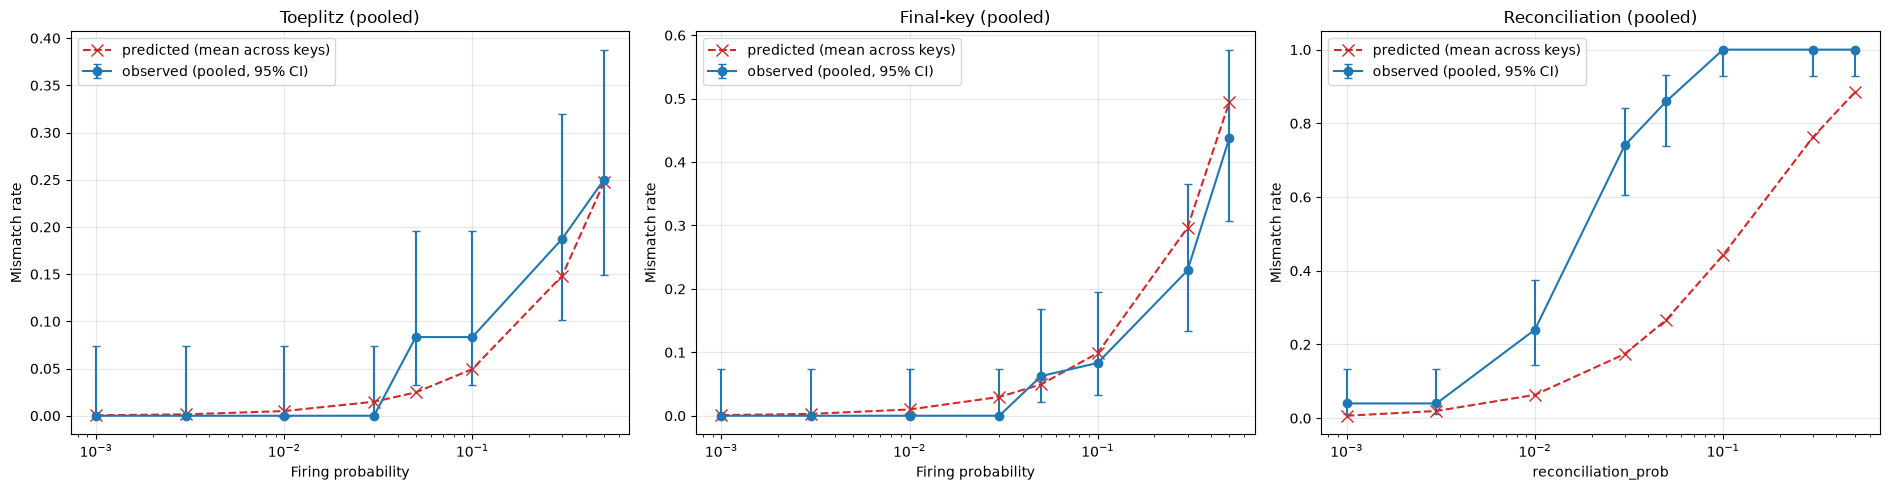

In [29]:
def plot_pooled_validation(df_clean, key_pairs_df, ell_func, p1, label, ax, prob_col="prob"):
    probs = sorted(df_clean[prob_col].unique())
    pooled_obs, pooled_lo, pooled_hi, mean_pred = [], [], [], []

    for prob in probs:
        sub = df_clean[df_clean[prob_col] == prob]
        successes = sub["mismatch"].sum()
        n_total = len(sub)
        p_hat, lo, hi = wilson_ci(successes, n_total)
        pooled_obs.append(p_hat); pooled_lo.append(lo); pooled_hi.append(hi)

        # Average the per-key PREDICTION at this probability (each key has its own ell)
        key_preds = []
        for key_idx in sub["key_index"].unique():
            krow = key_pairs_df.iloc[key_idx]
            n_bits, k_pe, Q = int(krow["n_bits"]), int(krow["k_pe"]), float(krow["qber"])
            ell, t_verify = ell_func(n_bits, k_pe, Q)
            key_preds.append(prob * (ell / (ell + t_verify)) * (p1 if p1 else 1.0))
        mean_pred.append(np.mean(key_preds))

    pooled_obs, pooled_lo, pooled_hi = np.array(pooled_obs), np.array(pooled_lo), np.array(pooled_hi)
    yerr_lower = np.clip(pooled_obs - pooled_lo, 0, None)
    yerr_upper = np.clip(pooled_hi - pooled_obs, 0, None)

    ax.errorbar(probs, pooled_obs, yerr=[yerr_lower, yerr_upper], fmt="o-",
                  capsize=3, label="observed (pooled, 95% CI)", color="tab:blue")
    ax.plot(probs, mean_pred, "x--", color="tab:red", label="predicted (mean across keys)", markersize=9)
    ax.set_xscale("log")
    ax.set_xlabel("Firing probability")
    ax.set_ylabel("Mismatch rate")
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

def plot_pooled_reconciliation(df, key_pairs_df, ax, M=4):
    probs = sorted(df["reconciliation_prob"].unique())
    pooled_obs, pooled_lo, pooled_hi, mean_pred = [], [], [], []

    for prob in probs:
        sub = df[df["reconciliation_prob"] == prob]
        successes = (~sub["keys_match"].fillna(True)).sum()
        n_total = len(sub)
        p_hat, lo, hi = wilson_ci(successes, n_total)
        pooled_obs.append(p_hat); pooled_lo.append(lo); pooled_hi.append(hi)

        key_preds = []
        for key_idx in sub["key_index"].unique():
            krow = key_pairs_df.iloc[key_idx]
            n_bits, Q = int(krow["n_bits"]), float(krow["qber"])
            key_preds.append(full_reconciliation_prediction(n_bits, Q, prob, M))
        mean_pred.append(np.mean(key_preds))

    pooled_obs, pooled_lo, pooled_hi = np.array(pooled_obs), np.array(pooled_lo), np.array(pooled_hi)
    yerr_lower = np.clip(pooled_obs - pooled_lo, 0, None)
    yerr_upper = np.clip(pooled_hi - pooled_obs, 0, None)

    ax.errorbar(probs, pooled_obs, yerr=[yerr_lower, yerr_upper], fmt="o-",
                  capsize=3, label="observed (pooled, 95% CI)", color="tab:blue")
    ax.plot(probs, mean_pred, "x--", color="tab:red", label="predicted (mean across keys)", markersize=9)
    ax.set_xscale("log")
    ax.set_xlabel("reconciliation_prob")
    ax.set_ylabel("Mismatch rate")
    ax.set_title("Reconciliation (pooled)")
    ax.legend()
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(19, 5))
plot_pooled_validation(toeplitz_clean, key_pairs_df, ell_asymptotic_actual, p1=0.5, label="Toeplitz (pooled)", ax=axes[0])
plot_pooled_validation(final_key_clean, key_pairs_df, ell_asymptotic_actual, p1=None, label="Final-key (pooled)", ax=axes[1])
plot_pooled_reconciliation(reconciliation_df, key_pairs_df, ax=axes[2])
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_pooled_all_faults.png"), dpi=150)
plt.show()

In [30]:
# Apply the same baseline-contamination logic to mock reconciliation, if it has the column
recon_mock = mock_clean[mock_clean["fault_type"] == "reconciliation"].copy() if "mock_clean" in dir() else \
             mock_df[mock_df["fault_type"] == "reconciliation"].copy()

print("=== Reconciliation: real (fixed) vs Mock -- direct keys_match comparison ===")
for prob in sorted(reconciliation_df["reconciliation_prob"].unique()):
    real_g = reconciliation_df[reconciliation_df["reconciliation_prob"] == prob]
    mock_g = recon_mock[recon_mock["reconciliation_prob"] == prob] if "reconciliation_prob" in recon_mock.columns \
             else recon_mock[recon_mock["prob"] == prob]
    if len(real_g) == 0 or len(mock_g) == 0:
        print(f"  prob={prob}: skipped -- missing data on one side")
        continue
    s1, n1 = (~real_g["keys_match"].fillna(True)).sum(), len(real_g)
    s2, n2 = (~mock_g["keys_match"].fillna(True)).sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    sig = "**" if p < 0.05 else ""
    print(f"  prob={prob:<6}: real={s1}/{n1} ({s1/n1:.2f}), mock={s2}/{n2} ({s2/n2:.2f}), "
          f"z={z:.3f}, p={p:.4f} {sig}")

=== Reconciliation: real (fixed) vs Mock -- direct keys_match comparison ===
  prob=0.001 : real=2/50 (0.04), mock=12/200 (0.06), z=-0.550, p=0.5822 
  prob=0.003 : real=2/50 (0.04), mock=22/200 (0.11), z=-1.503, p=0.1329 
  prob=0.01  : real=12/50 (0.24), mock=54/200 (0.27), z=-0.430, p=0.6669 
  prob=0.03  : real=37/50 (0.74), mock=162/200 (0.81), z=-1.099, p=0.2719 
  prob=0.05  : real=43/50 (0.86), mock=176/200 (0.88), z=-0.384, p=0.7011 
  prob=0.1   : real=50/50 (1.00), mock=200/200 (1.00), z=nan, p=nan 
  prob=0.3   : real=50/50 (1.00), mock=200/200 (1.00), z=nan, p=nan 
  prob=0.5   : real=50/50 (1.00), mock=200/200 (1.00), z=nan, p=nan 


In [31]:
def ell_finite_key_actual(n, k_pe, Q):
    ell, r, t, nu = finite_key_output_length(n, k_pe, Q)
    ell = int(max(0, round(ell)))
    t_verify = int(max(1, round(t)))  # also cast t/t_verify, same risk
    return ell, t_verify

In [32]:
print(f"{'key':<5} {'n_bits':<8} {'k_pe':<6} {'qber':<10} {'ell_finite':<12} {'r':<12} {'t':<10} {'nu':<10}")
print("-" * 75)

for key_idx in range(len(key_pairs_df)):
    row = key_pairs_df.iloc[key_idx]
    n_bits, k_pe, Q = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])

    ell, r, t, nu = finite_key_output_length(n_bits, k_pe, Q)

    print(f"{key_idx:<5} {n_bits:<8} {k_pe:<6} {Q:<10.4f} {ell:<12} {r:<12.2f} {t:<10.2f} {nu:<10.4f}")

key   n_bits   k_pe   qber       ell_finite   r            t          nu        
---------------------------------------------------------------------------
0     3504     390    0.0128     23           430.27       11.77      0.2609    
1     3409     379    0.0158     1            494.65       11.74      0.2646    
2     3360     374    0.0027     337          116.31       11.71      0.2664    
3     3431     382    0.0026     363          116.42       11.74      0.2636    
4     3456     385    0.0052     269          206.21       11.75      0.2626    


In [33]:
print(f"{'key':<5} {'ell_asymptotic':<16} {'ell_placeholder':<16} {'ell_finite':<12} {'reduction_%':<12}")
print("-" * 65)

from randextract import ToeplitzHashing

def placeholder_key_length(n_bits):
    """QFabric's default extraction-length heuristic (randextract library) --
    NOT derived from the finite-key security literature."""
    return ToeplitzHashing.calculate_length(
        extractor_type="quantum", input_length=n_bits,
        relative_source_entropy=0.5, error_bound=1e-6,
    )

for key_idx in range(len(key_pairs_df)):
    row = key_pairs_df.iloc[key_idx]
    n_bits, k_pe, Q = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])

    ell_asymp = asymptotic_key_length(n_bits, Q)
    ell_place = placeholder_key_length(n_bits)
    ell_finite, _, _, _ = finite_key_output_length(n_bits, k_pe, Q)

    reduction = 100 * (1 - ell_finite / ell_asymp) if ell_asymp > 0 else float("nan")

    print(f"{key_idx:<5} {ell_asymp:<16} {ell_place:<16} {ell_finite:<12} {reduction:<12.2f}")

key   ell_asymptotic   ell_placeholder  ell_finite   reduction_% 
-----------------------------------------------------------------
0     2810             1714             23           99.18       
1     2608             1666             1            99.96       
2     3180             1642             337          89.40       
3     3251             1677             363          88.83       
4     3131             1690             269          91.41       


In [34]:
print("=== Mismatch rate vs QBER, per key, per fault type ===\n")

fault_data = {
    "toeplitz": (toeplitz_clean, "prob"),
    "final_key": (final_key_clean, "prob"),
    "verify_digest": (verify_digest_clean, "prob"),
    "reconciliation": (reconciliation_df, "reconciliation_prob"),
}

for fault_type, (df, prob_col) in fault_data.items():
    print(f"--- {fault_type} ---")
    for prob in sorted(df[prob_col].unique()):
        sub = df[df[prob_col] == prob]
        per_key = sub.groupby("key_index").apply(
            lambda g: pd.Series({
                "qber": g["qber"].iloc[0],
                "n_trials": len(g),
                "mismatch_rate": (~g["keys_match"].fillna(True)).mean(),
            })
        ).sort_values("qber")
        print(f"  prob={prob}")
        for key_idx, row in per_key.iterrows():
            print(f"    key{int(key_idx)}: qber={row['qber']:.4f}  "
                  f"mismatch_rate={row['mismatch_rate']:.3f}  (n={int(row['n_trials'])})")
    print()

=== Mismatch rate vs QBER, per key, per fault type ===

--- toeplitz ---
  prob=0.001
    key3: qber=0.0026  mismatch_rate=0.000  (n=10)
    key2: qber=0.0027  mismatch_rate=0.000  (n=9)
    key4: qber=0.0052  mismatch_rate=0.000  (n=9)
    key0: qber=0.0128  mismatch_rate=0.000  (n=10)
    key1: qber=0.0158  mismatch_rate=0.000  (n=10)
  prob=0.003
    key3: qber=0.0026  mismatch_rate=0.000  (n=10)
    key2: qber=0.0027  mismatch_rate=0.000  (n=9)
    key4: qber=0.0052  mismatch_rate=0.000  (n=9)
    key0: qber=0.0128  mismatch_rate=0.000  (n=10)
    key1: qber=0.0158  mismatch_rate=0.000  (n=10)
  prob=0.01
    key3: qber=0.0026  mismatch_rate=0.000  (n=10)
    key2: qber=0.0027  mismatch_rate=0.000  (n=9)
    key4: qber=0.0052  mismatch_rate=0.000  (n=9)
    key0: qber=0.0128  mismatch_rate=0.000  (n=10)
    key1: qber=0.0158  mismatch_rate=0.000  (n=10)
  prob=0.03
    key3: qber=0.0026  mismatch_rate=0.000  (n=10)
    key2: qber=0.0027  mismatch_rate=0.000  (n=9)
    key4: qber=0.

In [35]:
rows = []
for fault_type, (df, prob_col) in fault_data.items():
    for prob in sorted(df[prob_col].unique()):
        sub = df[df[prob_col] == prob]
        for key_idx in sorted(sub["key_index"].unique()):
            key_sub = sub[sub["key_index"] == key_idx]
            rows.append({
                "fault_type": fault_type,
                "prob": prob,
                "key_index": key_idx,
                "qber": key_sub["qber"].iloc[0],
                "n_trials": len(key_sub),
                "mismatch_rate": (~key_sub["keys_match"].fillna(True)).mean(),
            })

summary_table = pd.DataFrame(rows).sort_values(["fault_type", "prob", "qber"])
print(summary_table.to_string(index=False))

    fault_type  prob  key_index     qber  n_trials  mismatch_rate
     final_key 0.001          3 0.002618        10       0.000000
     final_key 0.001          2 0.002674         9       0.000000
     final_key 0.001          4 0.005195         9       0.000000
     final_key 0.001          0 0.012821        10       0.000000
     final_key 0.001          1 0.015831        10       0.000000
     final_key 0.003          3 0.002618        10       0.000000
     final_key 0.003          2 0.002674         9       0.000000
     final_key 0.003          4 0.005195         9       0.000000
     final_key 0.003          0 0.012821        10       0.000000
     final_key 0.003          1 0.015831        10       0.000000
     final_key 0.010          3 0.002618        10       0.000000
     final_key 0.010          2 0.002674         9       0.000000
     final_key 0.010          4 0.005195         9       0.000000
     final_key 0.010          0 0.012821        10       0.000000
     final

In [36]:
for fault_type, (df, prob_col) in fault_data.items():
    print(f"--- {fault_type}: overall mismatch rate by key (all probabilities pooled) ---")
    per_key = df.groupby("key_index").apply(
        lambda g: pd.Series({
            "qber": g["qber"].iloc[0],
            "n_trials": len(g),
            "mismatch_rate": (~g["keys_match"].fillna(True)).mean(),
        })
    ).sort_values("qber")
    print(per_key.to_string())
    print()

--- toeplitz: overall mismatch rate by key (all probabilities pooled) ---
               qber  n_trials  mismatch_rate
key_index                                   
3          0.002618      80.0       0.062500
2          0.002674      72.0       0.055556
4          0.005195      72.0       0.083333
0          0.012821      80.0       0.050000
1          0.015831      80.0       0.125000

--- final_key: overall mismatch rate by key (all probabilities pooled) ---
               qber  n_trials  mismatch_rate
key_index                                   
3          0.002618      80.0       0.125000
2          0.002674      72.0       0.152778
4          0.005195      72.0       0.097222
0          0.012821      80.0       0.050000
1          0.015831      80.0       0.087500

--- verify_digest: overall mismatch rate by key (all probabilities pooled) ---
               qber  n_trials  mismatch_rate
key_index                                   
3          0.002618      80.0            0.0
2    

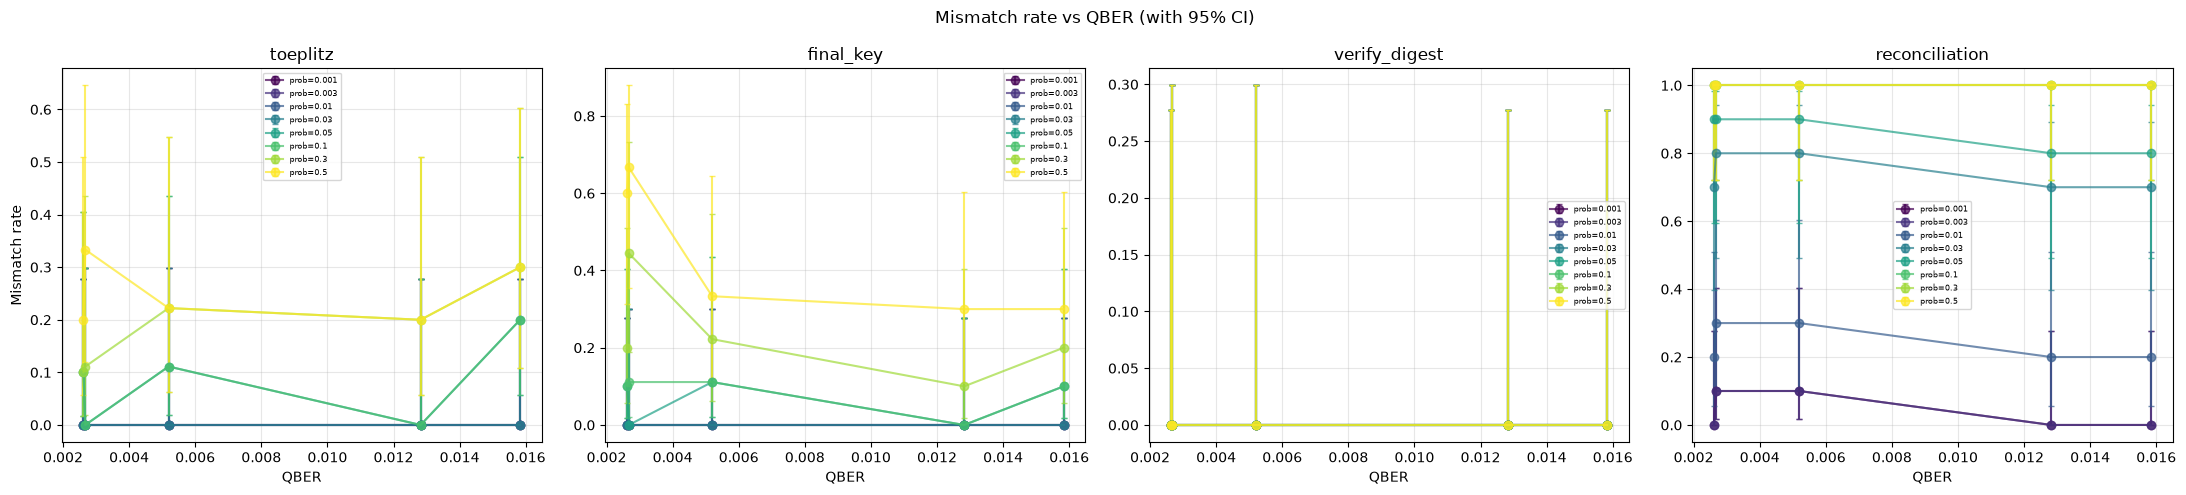

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (fault_type, (df, prob_col)) in zip(axes, fault_data.items()):
    probs = sorted(df[prob_col].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(probs)))

    for prob, color in zip(probs, colors):
        sub = df[df[prob_col] == prob]
        rows = []
        for key_idx in sorted(sub["key_index"].unique()):
            key_sub = sub[sub["key_index"] == key_idx]
            successes = (~key_sub["keys_match"].fillna(True)).sum()
            p_hat, lo, hi = wilson_ci(successes, len(key_sub))
            rows.append({"qber": key_sub["qber"].iloc[0], "mean": p_hat, "lo": lo, "hi": hi})
        per_key = pd.DataFrame(rows).sort_values("qber")

        yerr_lo = np.clip(per_key["mean"] - per_key["lo"], 0, None)
        yerr_hi = np.clip(per_key["hi"] - per_key["mean"], 0, None)
        ax.errorbar(per_key["qber"], per_key["mean"], yerr=[yerr_lo, yerr_hi],
                       fmt="o-", color=color, label=f"prob={prob}", alpha=0.7, capsize=2)

    ax.set_title(fault_type)
    ax.set_xlabel("QBER")
    ax.legend(fontsize=6, loc="best")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mismatch rate")
plt.suptitle("Mismatch rate vs QBER (with 95% CI)")
plt.tight_layout()
plt.show()

In [38]:
Q_range = np.linspace(0.003, 0.02, 10)
for prob in [0.01, 0.03, 0.1]:
    preds = [full_reconciliation_prediction(3500, Q, prob) for Q in Q_range]
    print(f"prob={prob}: predicted mismatch rate vs Q = {[f'{p:.3f}' for p in preds]}")

prob=0.01: predicted mismatch rate vs Q = ['0.018', '0.041', '0.054', '0.067', '0.084', '0.099', '0.117', '0.130', '0.138', '0.156']
prob=0.03: predicted mismatch rate vs Q = ['0.053', '0.118', '0.153', '0.189', '0.233', '0.269', '0.314', '0.342', '0.361', '0.400']
prob=0.1: predicted mismatch rate vs Q = ['0.168', '0.344', '0.429', '0.507', '0.592', '0.652', '0.719', '0.756', '0.779', '0.822']


In [39]:
toeplitz_fk_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_allkeys_finitekey.csv"))
final_key_fk_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_finalkey_allkeys_finitekey.csv"))
reconciliation_fk_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_allkeys_finitekey.csv"))
verify_digest_fk_df = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_verifydigest_allkeys_finitekey.csv"))

for df in [toeplitz_fk_df, final_key_fk_df, verify_digest_fk_df]:
    df["mismatch"] = ~df["keys_match"].fillna(False)
    df["is_baseline_contaminated"] = df.apply(is_baseline_contaminated, axis=1)

toeplitz_fk_clean = toeplitz_fk_df[~toeplitz_fk_df["is_baseline_contaminated"]].copy()
final_key_fk_clean = final_key_fk_df[~final_key_fk_df["is_baseline_contaminated"]].copy()
verify_digest_fk_clean = verify_digest_fk_df[~verify_digest_fk_df["is_baseline_contaminated"]].copy()

print(f"toeplitz_fk: {toeplitz_fk_df['is_baseline_contaminated'].sum()}/{len(toeplitz_fk_df)} contaminated")
print(f"final_key_fk: {final_key_fk_df['is_baseline_contaminated'].sum()}/{len(final_key_fk_df)} contaminated")
print(f"verify_digest_fk: {verify_digest_fk_df['is_baseline_contaminated'].sum()}/{len(verify_digest_fk_df)} contaminated")

toeplitz_fk: 16/400 contaminated
final_key_fk: 16/400 contaminated
verify_digest_fk: 16/400 contaminated


In [40]:
def ell_finite_key_actual(n, k_pe, Q):
    ell, r, t, nu = finite_key_output_length(n, k_pe, Q)
    return max(0, ell), t

print(f"{'key':<5} {'qber':<10} {'ell_asymptotic':<16} {'ell_finite':<12} {'ell_finite/ell_asymp':<20}")
for key_idx in range(len(key_pairs_df)):
    row = key_pairs_df.iloc[key_idx]
    n_bits, k_pe, Q = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])
    ell_a, _ = ell_asymptotic_actual(n_bits, k_pe, Q)
    ell_fk, _ = ell_finite_key_actual(n_bits, k_pe, Q)
    ratio = ell_fk / ell_a if ell_a > 0 else float("nan")
    print(f"{key_idx:<5} {Q:<10.4f} {ell_a:<16} {ell_fk:<12} {ratio:<20.4f}")

key   qber       ell_asymptotic   ell_finite   ell_finite/ell_asymp
0     0.0128     2810             23           0.0082              
1     0.0158     2608             1            0.0004              
2     0.0027     3180             337          0.1060              
3     0.0026     3251             363          0.1117              
4     0.0052     3131             269          0.0859              


In [41]:
chi2_stat, dof, p_val = chi_square_goodness_of_fit(toeplitz_fk_clean, key_pairs_df, ell_finite_key_actual, p1=0.5)
print(f"Toeplitz (finite_key) goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")

chi2_stat, dof, p_val = chi_square_goodness_of_fit(final_key_fk_clean, key_pairs_df, ell_finite_key_actual, p1=None)
print(f"Final-key (finite_key) goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")

Toeplitz (finite_key) goodness-of-fit: chi2=10.59, dof=40, p=1.0000
Final-key (finite_key) goodness-of-fit: chi2=10.76, dof=40, p=1.0000


In [42]:
def mismatch_series(df, col="keys_match"):
    return ~df[col].fillna(True).astype(bool)

# Recompute mismatch for the FINITE-KEY dataframes specifically
toeplitz_fk_df["mismatch"] = mismatch_series(toeplitz_fk_df)
final_key_fk_df["mismatch"] = mismatch_series(final_key_fk_df)

toeplitz_fk_clean = toeplitz_fk_df[~toeplitz_fk_df["is_baseline_contaminated"]].copy()
final_key_fk_clean = final_key_fk_df[~final_key_fk_df["is_baseline_contaminated"]].copy()
for df in [toeplitz_clean, final_key_clean, verify_digest_clean,
             toeplitz_fk_clean, final_key_fk_clean, verify_digest_fk_clean]:
    df["mismatch"] = mismatch_series(df)

reconciliation_df["mismatch"] = mismatch_series(reconciliation_df)
reconciliation_fk_df["mismatch"] = mismatch_series(reconciliation_fk_df)

In [43]:
def chi_square_goodness_of_fit_reconciliation(df, key_pairs_df, M=4):
    chi2_stat = 0
    dof = 0
    for key_idx in sorted(df["key_index"].unique()):
        krow = key_pairs_df.iloc[key_idx]
        n_bits, Q = int(krow["n_bits"]), float(krow["qber"])
        sub = df[df["key_index"] == key_idx]
        for prob in sorted(sub["reconciliation_prob"].unique()):
            trials = sub[sub["reconciliation_prob"] == prob]
            n_trials = len(trials)
            observed_successes = trials["mismatch"].sum()  # use the fixed column, not keys_match directly
            predicted_p = full_reconciliation_prediction(n_bits, Q, prob, M)
            predicted_p = min(max(predicted_p, 1e-6), 1 - 1e-6)
            expected_successes = n_trials * predicted_p
            expected_failures = n_trials * (1 - predicted_p)
            observed_failures = n_trials - observed_successes
            if expected_successes > 0:
                chi2_stat += (observed_successes - expected_successes) ** 2 / expected_successes
            if expected_failures > 0:
                chi2_stat += (observed_failures - expected_failures) ** 2 / expected_failures
            dof += 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, dof, p_value

reconciliation_fk_df["mismatch"] = mismatch_series(reconciliation_fk_df)
reconciliation_df["mismatch"] = mismatch_series(reconciliation_df)

chi2_stat, dof, p_val = chi_square_goodness_of_fit_reconciliation(reconciliation_fk_df, key_pairs_df)
print(f"Reconciliation (finite_key) goodness-of-fit: chi2={chi2_stat:.2f}, dof={dof}, p={p_val:.4f}")

print("\n=== Reconciliation: finite_key vs asymptotic mode ===")
for prob in sorted(set(reconciliation_df["reconciliation_prob"]) & set(reconciliation_fk_df["reconciliation_prob"])):
    real_g = reconciliation_df[reconciliation_df["reconciliation_prob"] == prob]
    fk_g = reconciliation_fk_df[reconciliation_fk_df["reconciliation_prob"] == prob]
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = fk_g["mismatch"].sum(), len(fk_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    print(f"  prob={prob:<6}: asymptotic={s1}/{n1} ({s1/n1:.2f}), finite_key={s2}/{n2} ({s2/n2:.2f}), "
          f"z={z:.3f}, p={p:.4f}")

Reconciliation (finite_key) goodness-of-fit: chi2=3245.34, dof=40, p=0.0000

=== Reconciliation: finite_key vs asymptotic mode ===
  prob=0.001 : asymptotic=2/50 (0.04), finite_key=2/50 (0.04), z=0.000, p=1.0000
  prob=0.003 : asymptotic=2/50 (0.04), finite_key=2/50 (0.04), z=0.000, p=1.0000
  prob=0.01  : asymptotic=12/50 (0.24), finite_key=11/50 (0.22), z=0.238, p=0.8122
  prob=0.03  : asymptotic=37/50 (0.74), finite_key=33/50 (0.66), z=0.873, p=0.3827
  prob=0.05  : asymptotic=43/50 (0.86), finite_key=40/50 (0.80), z=0.799, p=0.4245
  prob=0.1   : asymptotic=50/50 (1.00), finite_key=46/50 (0.92), z=2.041, p=0.0412
  prob=0.3   : asymptotic=50/50 (1.00), finite_key=47/50 (0.94), z=1.759, p=0.0786
  prob=0.5   : asymptotic=50/50 (1.00), finite_key=45/50 (0.90), z=2.294, p=0.0218


In [44]:
print("=== Toeplitz: finite_key vs asymptotic, per key/probability ===")
for key_idx in sorted(toeplitz_fk_clean["key_index"].unique()):
    print(f"\n  key{key_idx}:")
    asymp_g_all = toeplitz_clean[toeplitz_clean["key_index"] == key_idx]
    fk_g_all = toeplitz_fk_clean[toeplitz_fk_clean["key_index"] == key_idx]
    for prob in sorted(fk_g_all["prob"].unique()):
        asymp_g = asymp_g_all[asymp_g_all["prob"] == prob]
        fk_g = fk_g_all[fk_g_all["prob"] == prob]
        if len(asymp_g) == 0 or len(fk_g) == 0:
            continue
        s1, n1 = asymp_g["mismatch"].sum(), len(asymp_g)
        s2, n2 = fk_g["mismatch"].sum(), len(fk_g)
        z, p = two_proportion_ztest(s1, n1, s2, n2)
        sig = "**" if p < 0.05 else ""
        direction = "LOWER (as predicted)" if s2/n2 < s1/n1 else "NOT lower"
        print(f"    prob={prob:<6}: asymptotic={s1}/{n1} ({s1/n1:.2f}), finite_key={s2}/{n2} ({s2/n2:.2f}), "
              f"z={z:.3f}, p={p:.4f} {sig}  [{direction}]")

print("\n=== Final-key: finite_key vs asymptotic, per key/probability ===")
for key_idx in sorted(final_key_fk_clean["key_index"].unique()):
    print(f"\n  key{key_idx}:")
    asymp_g_all = final_key_clean[final_key_clean["key_index"] == key_idx]
    fk_g_all = final_key_fk_clean[final_key_fk_clean["key_index"] == key_idx]
    for prob in sorted(fk_g_all["prob"].unique()):
        asymp_g = asymp_g_all[asymp_g_all["prob"] == prob]
        fk_g = fk_g_all[fk_g_all["prob"] == prob]
        if len(asymp_g) == 0 or len(fk_g) == 0:
            continue
        s1, n1 = asymp_g["mismatch"].sum(), len(asymp_g)
        s2, n2 = fk_g["mismatch"].sum(), len(fk_g)
        z, p = two_proportion_ztest(s1, n1, s2, n2)
        sig = "**" if p < 0.05 else ""
        direction = "LOWER (as predicted)" if s2/n2 < s1/n1 else "NOT lower"
        print(f"    prob={prob:<6}: asymptotic={s1}/{n1} ({s1/n1:.2f}), finite_key={s2}/{n2} ({s2/n2:.2f}), "
              f"z={z:.3f}, p={p:.4f} {sig}  [{direction}]")

=== Toeplitz: finite_key vs asymptotic, per key/probability ===

  key0:
    prob=0.001 : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.003 : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.01  : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.03  : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.05  : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.1   : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.3   : asymptotic=2/10 (0.20), finite_key=1/10 (0.10), z=0.626, p=0.5312   [LOWER (as predicted)]
    prob=0.5   : asymptotic=2/10 (0.20), finite_key=1/10 (0.10), z=0.626, p=0.5312   [LOWER (as predicted)]

  key1:
    prob=0.001 : asymptotic=0/10 (0.00), finite_key=0/10 (0.00), z=nan, p=nan   [NOT lower]
    prob=0.003 : asymptotic=0/10 (0.00), finite_key=0/10 (

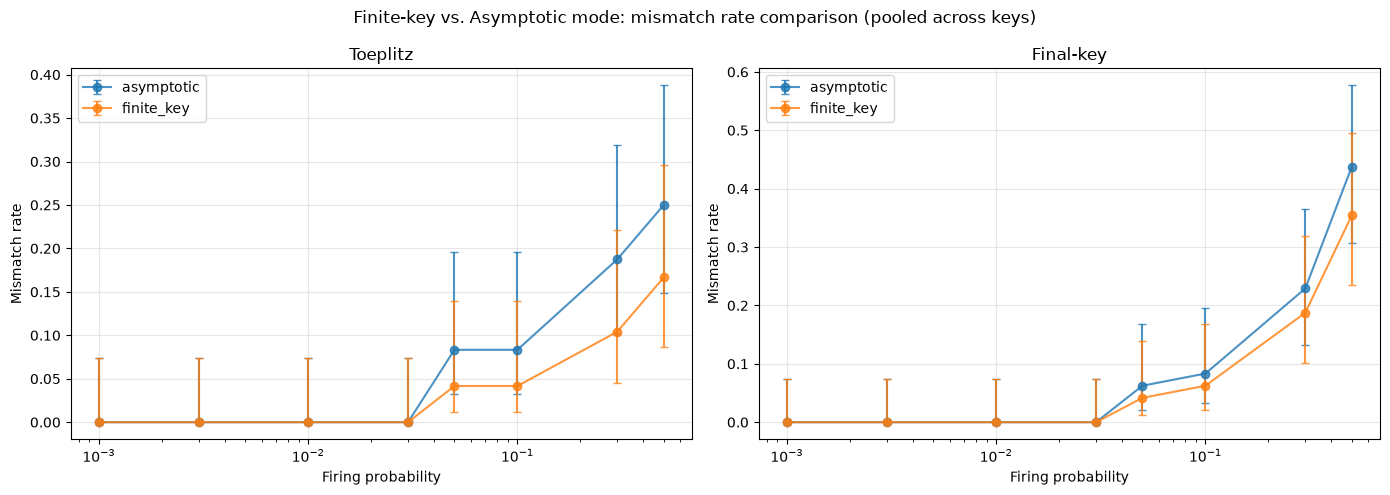

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, asymp_clean, fk_clean, p1) in zip(
    axes, [("Toeplitz", toeplitz_clean, toeplitz_fk_clean, 0.5),
            ("Final-key", final_key_clean, final_key_fk_clean, None)]):

    for mode_df, mode_name, color in [(asymp_clean, "asymptotic", "tab:blue"), (fk_clean, "finite_key", "tab:orange")]:
        probs = sorted(mode_df["prob"].unique())
        obs, lo_list, hi_list = [], [], []
        for prob in probs:
            sub = mode_df[mode_df["prob"] == prob]
            successes = sub["mismatch"].sum()
            p_hat, lo, hi = wilson_ci(successes, len(sub))
            obs.append(p_hat); lo_list.append(lo); hi_list.append(hi)
        obs, lo_list, hi_list = np.array(obs), np.array(lo_list), np.array(hi_list)
        yerr_lo = np.clip(obs - lo_list, 0, None)
        yerr_hi = np.clip(hi_list - obs, 0, None)
        ax.errorbar(probs, obs, yerr=[yerr_lo, yerr_hi], fmt="o-", capsize=3,
                       color=color, label=mode_name, alpha=0.8)

    ax.set_xscale("log")
    ax.set_xlabel("Firing probability")
    ax.set_ylabel("Mismatch rate")
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Finite-key vs. Asymptotic mode: mismatch rate comparison (pooled across keys)")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_finitekey_vs_asymptotic.png"), dpi=150)
plt.show()

In [47]:
def cohens_h(p1, p2):
    """Effect size for comparing two proportions. |h| < 0.2: small,
    ~0.5: medium, ~0.8: large (Cohen's own conventions)."""
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))


mock_df["mismatch"] = mismatch_series(mock_df)  # dtype-safe, not the raw ~ pattern
mock_df["is_baseline_contaminated"] = mock_df.apply(is_baseline_contaminated, axis=1) \
    if "remaining_errors_after_reconciliation" in mock_df.columns else False
mock_clean = mock_df[~mock_df["is_baseline_contaminated"]] if "is_baseline_contaminated" in mock_df.columns else mock_df

print("=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key ===")
for fault_name, real_clean in [("toeplitz", toeplitz_clean), ("final_key", final_key_clean)]:
    mock_sub_all = mock_clean[mock_clean["fault_type"] == fault_name]
    for prob in sorted(real_clean["prob"].unique()):
        real_g = real_clean[real_clean["prob"] == prob]
        mock_g = mock_sub_all[mock_sub_all["prob"] == prob]
        if len(mock_g) == 0:
            continue
        s1, n1 = real_g["mismatch"].sum(), len(real_g)
        s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
        z, p = two_proportion_ztest(s1, n1, s2, n2)
        h = cohens_h(s1 / n1, s2 / n2)
        sig = "**" if p < 0.05 else ""
        print(f"  {fault_name:<12} prob={prob:<6}: real={s1}/{n1}, mock={s2}/{n2}, "
              f"z={z:.3f}, p={p:.4f} {sig}, Cohen's h={h:.4f}")


recon_mock = mock_clean[mock_clean["fault_type"] == "reconciliation"].copy()
recon_mock["mismatch"] = mismatch_series(recon_mock)  # fixed: dtype-safe, not raw ~

reconciliation_df["mismatch"] = mismatch_series(reconciliation_df)  # same fix applied here

print("\n=== Reconciliation: real (fixed) vs Mock ===")
for prob in sorted(reconciliation_df["reconciliation_prob"].unique()):
    real_g = reconciliation_df[reconciliation_df["reconciliation_prob"] == prob]
    mock_g = recon_mock[recon_mock["reconciliation_prob"] == prob] if "reconciliation_prob" in recon_mock.columns \
             else recon_mock[recon_mock["prob"] == prob]
    if len(real_g) == 0 or len(mock_g) == 0:
        print(f"  prob={prob}: skipped -- missing data on one side")
        continue
    s1, n1 = real_g["mismatch"].sum(), len(real_g)
    s2, n2 = mock_g["mismatch"].sum(), len(mock_g)
    z, p = two_proportion_ztest(s1, n1, s2, n2)
    h = cohens_h(s1 / n1, s2 / n2)
    sig = "**" if p < 0.05 else ""
    print(f"  prob={prob:<6}: real={s1}/{n1} ({s1/n1:.2f}), mock={s2}/{n2} ({s2/n2:.2f}), "
          f"z={z:.3f}, p={p:.4f} {sig}, Cohen's h={h:.4f}")

=== Real (cleaned) vs Mock (cleaned): toeplitz/final_key ===
  toeplitz     prob=0.001 : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  toeplitz     prob=0.003 : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  toeplitz     prob=0.01  : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  toeplitz     prob=0.03  : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  toeplitz     prob=0.05  : real=4/48, mock=22/200, z=-0.542, p=0.5881 , Cohen's h=-0.0904
  toeplitz     prob=0.1   : real=4/48, mock=24/200, z=-0.721, p=0.4710 , Cohen's h=-0.1218
  toeplitz     prob=0.3   : real=9/48, mock=46/200, z=-0.636, p=0.5245 , Cohen's h=-0.1047
  toeplitz     prob=0.5   : real=12/48, mock=58/200, z=-0.553, p=0.5803 , Cohen's h=-0.0902
  final_key    prob=0.001 : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  final_key    prob=0.003 : real=0/48, mock=12/200, z=-1.740, p=0.0819 , Cohen's h=-0.4949
  final_key    prob=0.01  : 

In [6]:
"""
Full-distribution reconciliation-fault mismatch model.
Validated against Monte Carlo simulation at small n (n=8) before running at real scale.
Computes P_j(y) via Theorem 1/2 (Seet, Ng, Khoo - QCRYPT 2013) recursion,
then P_survive(j) as the distributional average (not point-estimate) hypergeometric
survival probability for a single injected fault bit.
"""
from math import comb, ceil, lgamma, log
import numpy as np

def log_comb(n, k):
    if k < 0 or k > n:
        return float('-inf')
    return lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)

# ---------------- USER INPUTS ----------------
N = 3000          # key length (set to your real n_bits)
QBER = 0.03        # set to your real measured QBER for this key pair
# ----------------------------------------------

def m_block(iteration_nr, qber):
    if iteration_nr == 1:
        return ceil(0.73 / qber)
    return 2 * m_block(iteration_nr - 1, qber)

def poly_pow(coeffs, power):
    result = np.array([1.0])
    base = np.array(coeffs)
    for _ in range(power):
        result = np.convolve(result, base)
    return result

def f_even_odd_coeffs(k):
    plus = np.array([comb(k, i) for i in range(k + 1)], dtype=float)
    minus = np.array([comb(k, i) * ((-1) ** i) for i in range(k + 1)], dtype=float)
    f_even = (plus + minus) / 2
    f_odd = (plus - minus) / 2
    return f_even, f_odd

def C_ijy(k, num_blocks, j, y, n):
    f_even, f_odd = f_even_odd_coeffs(k)
    odd_pow = j - y
    even_pow = num_blocks - odd_pow
    if odd_pow < 0 or even_pow < 0:
        return 0.0
    poly = poly_pow(f_odd, odd_pow) if odd_pow > 0 else np.array([1.0])
    poly2 = poly_pow(f_even, even_pow) if even_pow > 0 else np.array([1.0])
    full = np.convolve(poly, poly2)
    return full[j] if j < len(full) else 0.0

def delta(k, num_blocks, j, y, n):
    if j - y < 0 or j - y > num_blocks:
        return 0.0
    return comb(num_blocks, j - y) / comb(n, j) * C_ijy(k, num_blocks, j, y, n)

def apply_theorem1(P_prev, k, n, max_y=None):
    """Propagate a full distribution P_prev (dict y->prob) forward one Cascade pass
    with block size k. Restricts to a reasonable y-range around the support of P_prev
    to keep this tractable at large n."""
    num_blocks = n // k
    if max_y is None:
        max_y = max(P_prev.keys())
    P_next = {}
    for y in range(max_y + 1):
        s = 0.0
        for j in range(y, min(y + num_blocks, max_y) + 1):
            if j in P_prev and P_prev[j] > 1e-14:
                s += P_prev[j] * delta(k, num_blocks, j, y, n)
        if s > 1e-14:
            P_next[y] = s
    return P_next

def initial_distribution(n, qber, truncate_prob=1e-12):
    """P0(l), truncated to a reasonable window around the mean to keep this tractable
    at large n (binomial concentrates tightly around n*qber)."""
    mean = n * qber
    std = (n * qber * (1 - qber)) ** 0.5
    lo = max(0, int(mean - 8 * std))
    hi = min(n, int(mean + 8 * std))
    dist = {}
    for l in range(lo, hi + 1):
        # use log-space binomial to avoid overflow at large n
        logp = (log_comb(n, l) + l * log(qber) + (n - l) * log(1 - qber))
        dist[l] = np.exp(logp)
    total = sum(dist.values())
    return {k: v / total for k, v in dist.items()}  # renormalize after truncation

def P_survive_distributional(P_dist, N, m):
    """P(fault's block stays even), averaged over the full background-error
    distribution P_dist, rather than a single point estimate."""
    pop = N - 1
    sample = m - 1
    denom = comb(pop, sample)
    total = 0.0
    for y, p_y in P_dist.items():
        y = int(round(y))
        s = 0  # keep as exact Python int until final division -- avoids float overflow
        for i in range(0, sample + 1, 2):  # even i
            if i <= y and (sample - i) <= (pop - y):
                s += comb(y, i) * comb(pop - y, sample - i)
        total += p_y * (s / denom)
    return total

def P_survive_point_estimate(K, N, m):
    """Old point-estimate version, for comparison."""
    K = int(round(K))
    pop = N - 1
    sample = m - 1
    denom = comb(pop, sample)
    s = 0
    for i in range(0, sample + 1, 2):
        if i <= K and (sample - i) <= (pop - K):
            s += comb(K, i) * comb(pop - K, sample - i)
    return s / denom

def P_odd_point(K, N, m):
    K = int(round(K))
    denom = comb(N, m)
    s = 0
    for i in range(1, m + 1, 2):
        if i <= K and (m - i) <= (N - K):
            s += comb(K, i) * comb(N - K, m - i)
    return s / denom

# ---------------- RUN: full-distribution version ----------------
m_sizes = [m_block(i, QBER) for i in range(1, 5)]
print("Block sizes (m1..m4):", m_sizes)

P0 = initial_distribution(N, QBER)
dists = [P0]
survive_dist = []
for i, m in enumerate(m_sizes, start=1):
    P_survive_dist = P_survive_distributional(dists[-1], N, m)
    survive_dist.append(P_survive_dist)
    P_next = apply_theorem1(dists[-1], m, N)
    dists.append(P_next)

print("\nFull-distribution P_survive per pass:", survive_dist)
print("P(mismatch | inject pass1), full dist =", np.prod(survive_dist))
print("P(mismatch | inject pass3), full dist =", np.prod(survive_dist[2:]))

# ---------------- RUN: point-estimate version (old, for comparison) ----------------
K = N * QBER
survive_point = []
for m in m_sizes:
    ps = P_survive_point_estimate(K, N, m)
    survive_point.append(ps)
    K = K - (N / m) * P_odd_point(K, N, m)

print("\nPoint-estimate P_survive per pass:", survive_point)
print("P(mismatch | inject pass1), point estimate =", np.prod(survive_point))
print("P(mismatch | inject pass3), point estimate =", np.prod(survive_point[2:]))

Block sizes (m1..m4): [25, 50, 100, 200]

Full-distribution P_survive per pass: [np.float64(0.613192252233667), np.float64(0.6234199332101492), np.float64(0.643092395282815), np.float64(0.679537053929165)]
P(mismatch | inject pass1), full dist = 0.16705668535111107
P(mismatch | inject pass3), full dist = 0.43700511169473416

Point-estimate P_survive per pass: [0.6118124853610937, 0.6173196820052623, 0.6354283274281975, 0.6595659663653783]
P(mismatch | inject pass1), point estimate = 0.15828992342141698
P(mismatch | inject pass3), point estimate = 0.4191068988361152


In [4]:
from math import comb, ceil
from pathlib import Path
import pandas as pd
import numpy as np

def m_block(iteration_nr, qber):
    if iteration_nr == 1:
        return ceil(0.73 / qber)
    return 2 * m_block(iteration_nr - 1, qber)

def P_survive_point_estimate(K, N, m):
    K = int(round(K))
    pop = N - 1
    sample = m - 1
    denom = comb(pop, sample)
    s = 0
    for i in range(1, sample + 1, 2):  # ODD i -- fault contributes 1 (odd) already;
                                        # need odd+odd=even total to survive
        if i <= K and (sample - i) <= (pop - K):
            s += comb(K, i) * comb(pop - K, sample - i)
    return s / denom

def P_odd_point(K, N, m):
    K = int(round(K))
    denom = comb(N, m)
    s = 0
    for i in range(1, m + 1, 2):
        if i <= K and (m - i) <= (N - K):
            s += comb(K, i) * comb(N - K, m - i)
    return s / denom

In [5]:
metadata_path = Path.home() / "work" / "qkd-dependability" / "results" / "key_pairs_metadata.csv"
key_pairs_df = pd.read_csv(str(metadata_path))
print(key_pairs_df)

   index  m_sifted  k_pe  n_bits      qber  \
0      0      3894   390    3504  0.012821   
1      1      3788   379    3409  0.015831   
2      2      3734   374    3360  0.002674   
3      3      3813   382    3431  0.002618   
4      4      3841   385    3456  0.005195   

                                          alice_path  \
0  /home/fabric/work/qkd-dependability/results/al...   
1  /home/fabric/work/qkd-dependability/results/al...   
2  /home/fabric/work/qkd-dependability/results/al...   
3  /home/fabric/work/qkd-dependability/results/al...   
4  /home/fabric/work/qkd-dependability/results/al...   

                                            bob_path  \
0  /home/fabric/work/qkd-dependability/results/bo...   
1  /home/fabric/work/qkd-dependability/results/bo...   
2  /home/fabric/work/qkd-dependability/results/bo...   
3  /home/fabric/work/qkd-dependability/results/bo...   
4  /home/fabric/work/qkd-dependability/results/bo...   

                                      alice_raw_p

In [7]:
def run_reconciliation_fault_model(n_i, q_i):
    m_sizes = [m_block(i, q_i) for i in range(1, 5)]
    K = n_i * q_i
    survive = []
    for m in m_sizes:
        ps = P_survive_point_estimate(K, n_i, m)
        survive.append(ps)
        K = K - (n_i / m) * P_odd_point(K, n_i, m)
    mismatch_from_pass = [float(np.prod(survive[i:])) for i in range(4)]
    return m_sizes, survive, mismatch_from_pass

rows = []
for _, kp in key_pairs_df.iterrows():
    m_sizes, survive, mismatch_from_pass = run_reconciliation_fault_model(kp["n_bits"], kp["qber"])
    rows.append({
        "index": kp["index"], "n_bits": kp["n_bits"], "qber": kp["qber"],
        "m1": m_sizes[0], "m2": m_sizes[1], "m3": m_sizes[2], "m4": m_sizes[3],
        "survive_p1": survive[0], "survive_p2": survive[1], "survive_p3": survive[2], "survive_p4": survive[3],
        "P_mismatch_inject_p1": mismatch_from_pass[0],
        "P_mismatch_inject_p2": mismatch_from_pass[1],
        "P_mismatch_inject_p3": mismatch_from_pass[2],
        "P_mismatch_inject_p4": mismatch_from_pass[3],
    })

results_df = pd.DataFrame(rows)
results_df

,index,n_bits,qber,m1,m2,m3,m4,survive_p1,survive_p2,survive_p3,survive_p4,P_mismatch_inject_p1,P_mismatch_inject_p2,P_mismatch_inject_p3,P_mismatch_inject_p4
0,0,3504,0.012821,57,114,228,456,0.613639,0.622176,0.642887,0.649901,0.159517,0.259953,0.417813,0.649901
1,1,3409,0.015831,47,94,188,376,0.611350,0.614887,0.638613,0.644021,0.154605,0.252891,0.411280,0.644021
2,2,3360,0.002674,274,548,1096,2192,0.600836,0.603150,0.560428,1.000000,0.203096,0.338022,0.560428,1.000000
3,3,3431,0.002618,279,558,1116,2232,0.601336,0.603714,0.561071,1.000000,0.203688,0.338727,0.561071,1.000000
4,4,3456,0.005195,141,282,564,1128,0.608324,0.620411,0.603026,0.673806,0.153351,0.252087,0.406323,0.673806


Total reconciliation-fault rows: 400
Rows with exactly 1 fault fired: 53
   key_index  observed_mismatch_rate  n_runs      qber
0          0                     1.0      11  0.012821
1          1                     1.0      11  0.015831
2          2                     1.0       9  0.002674
3          3                     1.0      11  0.002618
4          4                     1.0      11  0.005195
   key_index  predicted_mismatch  observed_mismatch_rate  n_runs      qber
0        0.0            0.159517                     1.0      11  0.012821
1        1.0            0.154605                     1.0      11  0.015831
2        2.0            0.203096                     1.0       9  0.002674
3        3.0            0.203688                     1.0      11  0.002618
4        4.0            0.153351                     1.0      11  0.005195


FileNotFoundError: [Errno 2] No such file or directory: 'results/reconciliation_predicted_vs_observed.png'

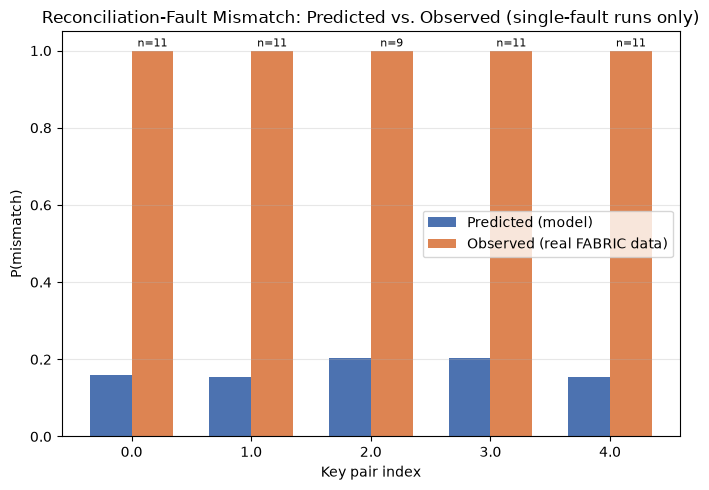

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# ---------- 1. Load and prep observed data ----------
observed_df = pd.read_csv("/home/fabric/work/qkd-dependability/results/sdc_realchannel_reconciliation_allkeys_asymptotic_fixed.csv")
recon_df = observed_df[observed_df["fault_type"] == "reconciliation"].copy()

# Parse faults_fired (stored as a string repr of a dict) to get the actual fault count per run
recon_df["n_faults_fired"] = recon_df["faults_fired"].apply(
    lambda d: ast.literal_eval(d).get("reconciliation_state", 0)
)

# Filter to exactly-one-fault runs -- the only regime that matches the model's assumption
single_fault_df = recon_df[recon_df["n_faults_fired"] == 1]

print(f"Total reconciliation-fault rows: {len(recon_df)}")
print(f"Rows with exactly 1 fault fired: {len(single_fault_df)}")
if len(single_fault_df) == 0:
    print("WARNING: no single-fault runs found -- check whether prob was ever low enough "
          "to produce exactly 1 fault, or whether faults_fired is being parsed correctly.")

# Observed mismatch rate per key, using keys_match == False as the mismatch indicator
observed_summary = (
    single_fault_df
    .groupby("key_index")
    .agg(observed_mismatch_rate=("keys_match", lambda s: (~s).mean()),
         n_runs=("keys_match", "count"),
         qber=("qber", "first"))
    .reset_index()
)
print(observed_summary)

# ---------- 2. Predicted values from the model ----------
predicted = []
for _, row in observed_summary.iterrows():
    # n_bits isn't directly in this summary -- pull from key_pairs_metadata
    n_i = key_pairs_df.loc[key_pairs_df["index"] == row["key_index"], "n_bits"].values[0]
    m_sizes, survive, mismatch_from_pass = run_reconciliation_fault_model(n_i, row["qber"])
    predicted.append({"key_index": row["key_index"], "predicted_mismatch": mismatch_from_pass[0]})
predicted_df = pd.DataFrame(predicted)

# ---------- 3. Merge and plot ----------
merged = predicted_df.merge(observed_summary, on="key_index")
print(merged)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(merged))
width = 0.35

ax.bar(x - width/2, merged["predicted_mismatch"], width, label="Predicted (model)", color="#4C72B0")
ax.bar(x + width/2, merged["observed_mismatch_rate"], width, label="Observed (real FABRIC data)", color="#DD8452")

for i, n in enumerate(merged["n_runs"]):
    ax.annotate(f"n={n}", (i + width/2, merged["observed_mismatch_rate"].iloc[i]),
                textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8)

ax.set_xlabel("Key pair index")
ax.set_ylabel("P(mismatch)")
ax.set_title("Reconciliation-Fault Mismatch: Predicted vs. Observed (single-fault runs only)")
ax.set_xticks(x)
ax.set_xticklabels(merged["key_index"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/reconciliation_predicted_vs_observed.png", dpi=300)
plt.show()